# Análisis de datos de Derechos de Uso de Aguas Subterráneas de la Dirección Nacional de Aguas (DINAGUA)

[Acceso al sitio oficial de DINAGUA](https://www.gub.uy/ministerio-ambiente/institucional/estructura-del-organismo/direccion-nacional-aguas)

## Paso 1: Definición del problema

Para este trabajo se utilizará un conjunto de datos proveniente del Sistema de Información Hídrica (SIH), el cual contiene información sobre los Derechos de Uso de Aguas otorgados por la Dirección Nacional de Aguas (DINAGUA) a personas físicas y jurídicas.

El SIH incluye datos asociados a obras de captación de aguas superficiales (tomas y embalses) y subterráneas (pozos). Los datos utilizados provienen una vez que el usuario solicita el derecho en el [*Registro de usuarios para trámites de derechos de uso de aguas*](https://www.gub.uy/tramites/registro-usuarios-tramites-derechos-uso-aguas).

Dado que el presente análisis se centra en los recursos hídricos subterráneos, se trabajará exclusivamente con los registros correspondientes a pozos.

A continuación, se presenta un breve glosario de las variables incluidas en la base de datos, con el objetivo de facilitar la comprensión de la información disponible y su posterior análisis.

Posteriormente, se realizará un proceso de exploración, limpieza y preparación de los datos para obtener un conjunto de datos adecuado para el entrenamiento de modelos de *Machine Learning*, con el fin de hacer foco a:

>Demora del trámite, es decir la brecha que existe emtre el tiempo de inscripcion y de resolución de una obra


## Paso 2: Recopilación de datos


| Campo | Descripción                                                                                                                                                                   |
|---------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Nro. GEX** | Número de expediente.                                                                                                                                                         |
| **Fecha Vencimiento** | Vencimiento del derecho de uso de aguas públicas. El plazo máximo es de 10 años, aunque depende del uso que se dará al agua.                                                  |
| **Estado** | Estado de la solicitud ante Dinagua: en estudio, pendiente de resolución o registrada.                                                                                        |
| **Regional** | Oficina de Dinagua encargada del estudio de la solicitud.                                                                                                                     |
| **Departamento** | Ubicación de la perforación.                                                                                                                                                  |
| **Fecha de Resolución** | Fecha en la que se emite el derecho de uso de aguas públicas.                                                                                                                 |
| **Caudal** | Metros cúbicos por hora (m³/h) de extracción de agua autorizados por Dinagua.                                                                                                 |
| **Volumen** | Volumen anual de extracción de agua. Se calcula multiplicando el caudal de la perforación por la cantidad de horas de uso diario, los días por mes y los meses de uso al año. |
| **Uso** | Clasificación general del uso que se dará al agua extraída.                                                                                                                   |
| **Destino** | Subcategoría de uso. Indica la finalidad específica del agua extraída.                                                                                                        |
| **Latitud** | Ubicación geográfica de la perforación.                                                                                                                                       |
| **Longitud** | Ubicación geográfica de la perforación.                                                                                                                                       |
| **Mes Inicio** | Mes del año en que comienza la extracción de agua.                                                                                                                            |
| **Mes Final** | Mes del año en que finaliza la extracción de agua.                                                                                                                            |
| **Horas x Año** | Cantidad de horas anuales de extracción de agua.                                                                                                                              |
| **Depto.-Padrón** | Identificación catastral de la ubicación de la perforación.                                                                                                                   |
| **Tipo de Obra** | Tipo de obra. En este caso corresponde a una perforación.                                                                                                                     |
| **Id Solicitud** | Identificador único de la solicitud.                                                                                                                                          |
| **Código Cuencas de Nivel 5** | Identificación de las cuencas hidrográficas de nivel 5.                                                                                                                       |
| **Sección y Localidad Catastral** | Sección y localidad catastral a la que pertenece el padrón.                                                                                                                   |
| **Cuencas de Nivel 3** | Identificación de las cuencas hidrográficas de nivel 3.                                                                                                                       |
| **Curso a Utilizar** | Dato no aplicable para perforaciones. Está relacionado con obras de agua superficial.                                                                                         |
| **Tipo de Acuífero** | Tipo de acuífero del cual se obtiene el agua subterránea. Puede ser fisurado, sedimentario o ambos.                                                                           |
| **Profundidad** | Profundidad de la perforación, expresada en metros.                                                                                                                           |
| **Diámetro** | Diámetro de la perforación, expresado en milímetros.                                                                                                                          |
| **Caudal Ensayado** | Caudal obtenido durante el ensayo de bombeo, expresado en m³/h.                                                                                                               |
| **Nivel Estático** | Profundidad a la que se encuentra el agua cuando el pozo no ha sido utilizado durante un período superior a 8 horas, medida respecto a la superficie del terreno.             |
| **Nivel Dinámico** | Profundidad a la que se encuentra el agua mientras el pozo está en uso, medida respecto a la superficie del terreno.                                                          |
| **Caudal Máximo** | Dato no útil.                                                                                                                                                                 |
| **Código Cuencas de Nivel 2** | Identificación de las cuencas hidrográficas de nivel 2.dato no útil                                                                                                           |
| **Producción** | Dato no útil.                                                                                                                                                                 |

### 2.a Importacíón de los datos y creación del DataFrame

Importamos las librerías básicas que vamos a trabajar

#### a. Pandas (`pd`)
Carga archivos (CSV, Excel), limpiar datos nulos, filtrar, agrupar y ordenar información.

#### b. NumPy (`np`)
Realiza cálculos numéricos masivos de forma instantánea usando matrices (*arrays*). Es la base sobre la que corren las demás librerías.

#### c. Matplotlib (`plt`)
Es el "lienzo" para gráficos.Permite construir y personalizar visualizaciones desde cero.

#### d. Seaborn (`sns`)
 Simplifica la creación de gráficos avanzados y modernos combinando estilo visual.



In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#### Importamos base de la ruta del computador

In [7]:
import os

ruta = r"C:\Georgi No Borrar\UCU\Python\Proyecto-python-diplomado\data\raw"

print(os.listdir(ruta))

['Base de Datos Grupo A.csv', 'README.md']


#### Verifico si archivo existe

In [8]:
import os

ruta = r"C:\Georgi No Borrar\UCU\Python\Proyecto-python-diplomado\data\raw"

print(os.path.exists(ruta))


True


Se utilizó la función `os.listdir()` para verificar el contenido de la carpeta de trabajo y confirmar el nombre exacto de los archivos disponibles. Esto permitió identificar el archivo de datos que posteriormente fue cargado en un DataFrame de Pandas para su análisis.

In [9]:
import os

ruta = r"C:\Georgi No Borrar\UCU\Python\Proyecto-python-diplomado\data\raw"

print(os.listdir(ruta))

['Base de Datos Grupo A.csv', 'README.md']


Debido a que el archivo contenía caracteres especiales en español, fue necesario especificar la codificación `latin-1` para evitar errores de lectura. Los datos fueron almacenados en un DataFrame denominado `df`, que será utilizado en las etapas posteriores de exploración, limpieza y análisis.

In [11]:
import pandas as pd

ruta = r"C:\Georgi No Borrar\UCU\Python\Proyecto-python-diplomado\data\raw\Base de Datos Grupo A.csv"

df = pd.read_csv(ruta, encoding="latin-1")

Antes de continuar con el **Paso 3: Análisis Descriptivo**, se realizó una verificación preliminar del conjunto de datos para comprobar que la carga del archivo se hubiera efectuado correctamente.

Para ello, se visualizaron los encabezados de las columnas mediante el método `df.columns.tolist()` y se inspeccionaron los primeros registros de la base de datos utilizando `df.head()`.

In [12]:
print(df.columns.tolist())

['Tipo de Solicitud', 'Nro. GEX', 'Fecha Vencimiento', 'Estado', 'Regional', 'Departamento', 'Tecnicos', 'Fecha de Solicitud', 'Fecha de Resolución', 'Fecha de Inscripción', 'Caudal', 'Volumen', 'Uso', 'Destino', 'Latitud', 'Longitud', 'Mes Inicio', 'Mes Final', 'Horas x Año', 'Depto.-Padrón', 'Tipo de Obra', 'Id Solicitud', 'Codigo Cuencas de nivel 5', 'Documento', 'Sección y localidad catastral', 'Cuencas de nivel 3', 'Curso a Utilizar', 'Área de Cuenca', 'Área de Embalse', 'Volúmen de Embalse', 'Altura Máxima', 'Tipo de acuifero', 'profundidad', 'Diámetro', 'Caudal Ensayado', 'Nivel Estático', 'Nivel Dinámico', 'Caudal Máximo', 'Codigo Cuencas de nivel 2', 'Accion Solicitud', 'Tipo Resolución', 'Producción']


In [13]:
df.head()


,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Caudal Máximo,Codigo Cuencas de nivel 2,Accion Solicitud,Tipo Resolución,Producción
0,Proyecto de Aprovechamiento,SGRH-03040200329-1436.001,NaN,En Estudio,FRAY BENTOS,COLONIA,"Appratto Mathisson, Martín",29/05/2003,NaN,NaN,...,32.0,0.15,7.5,8.0,NaN,NaN,21.0,Nueva,NaN,NaN
1,Proyecto de Aprovechamiento,SGRH-2006-10-004-0510-1-291,NaN,En Estudio,MONTEVIDEO,MONTEVIDEO,"Schipilov, Alejandro",29/11/2006,NaN,NaN,...,65.0,0.15,7.6,NaN,NaN,NaN,26.0,Nueva,NaN,NaN
2,Proyecto de Aprovechamiento,SGRH-2006-10-004-0510-1-293,NaN,En Estudio,MONTEVIDEO,MONTEVIDEO,"Schipilov, Alejandro",29/11/2006,NaN,NaN,...,45.0,0.15,3.6,NaN,NaN,NaN,26.0,Nueva,NaN,NaN
3,Proyecto de Aprovechamiento,SGRH-2007-10-004-0510-1-157,NaN,En Estudio,MONTEVIDEO,MONTEVIDEO,"Carrión, Roberto",28/06/2007,NaN,NaN,...,25.0,0.10,2.8,7.0,NaN,NaN,67.0,Nueva,NaN,NaN
4,Proyecto de Aprovechamiento,SGRH-2007-10-004-0510-1-294,NaN,En Estudio,FRAY BENTOS,COLONIA,"Manganelli, Alberto",21/11/2007,NaN,NaN,...,43.5,0.15,7.9,NaN,NaN,NaN,22.0,Nueva,NaN,NaN


## Paso 3: Análisis Descriptivo

#### 3.a DataFrame
Los datos fueron almacenados en el DataFrame `df`, una estructura de datos de Pandas que organiza la información en filas y columnas. A partir de esto se realizan las tareas de exploración, limpieza y análisis descriptivo de la base de datos.

In [14]:
df


,Tipo de Solicitud,Nro. GEX,Fecha Vencimiento,Estado,Regional,Departamento,Tecnicos,Fecha de Solicitud,Fecha de Resolución,Fecha de Inscripción,...,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Caudal Máximo,Codigo Cuencas de nivel 2,Accion Solicitud,Tipo Resolución,Producción
0,Proyecto de Aprovechamiento,SGRH-03040200329-1436.001,NaN,En Estudio,FRAY BENTOS,COLONIA,"Appratto Mathisson, Martín",29/05/2003,NaN,NaN,...,32.0,0.15,7.5,8.0,NaN,NaN,21.0,Nueva,NaN,NaN
1,Proyecto de Aprovechamiento,SGRH-2006-10-004-0510-1-291,NaN,En Estudio,MONTEVIDEO,MONTEVIDEO,"Schipilov, Alejandro",29/11/2006,NaN,NaN,...,65.0,0.15,7.6,NaN,NaN,NaN,26.0,Nueva,NaN,NaN
2,Proyecto de Aprovechamiento,SGRH-2006-10-004-0510-1-293,NaN,En Estudio,MONTEVIDEO,MONTEVIDEO,"Schipilov, Alejandro",29/11/2006,NaN,NaN,...,45.0,0.15,3.6,NaN,NaN,NaN,26.0,Nueva,NaN,NaN
3,Proyecto de Aprovechamiento,SGRH-2007-10-004-0510-1-157,NaN,En Estudio,MONTEVIDEO,MONTEVIDEO,"Carrión, Roberto",28/06/2007,NaN,NaN,...,25.0,0.10,2.8,7.0,NaN,NaN,67.0,Nueva,NaN,NaN
4,Proyecto de Aprovechamiento,SGRH-2007-10-004-0510-1-294,NaN,En Estudio,FRAY BENTOS,COLONIA,"Manganelli, Alberto",21/11/2007,NaN,NaN,...,43.5,0.15,7.9,NaN,NaN,NaN,22.0,Nueva,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 3.b Dimensiones
Para conocer las dimensiones del conjunto de datos se utiliza el atributo `df.shape`, que devuelve una tupla con el número de **filas** y **columnas** del DataFrame. Este paso permite identificar la cantidad total de registros disponibles para el análisis.

In [15]:
# Dimensiones
df.shape

(7698, 42)

Se reconcen 7698 filas y 42 columnas

#### 3.c Visión general del DataFrame
Para obtener una visión general de la estructura del conjunto de datos se utilizó el método `df.info()`.

Esta función permite visualizar información sobre el DataFrame, como puede ser la cantidad total de registros, el número de columnas, los nombres de las variables, el tipo de dato asociado a cada una y la cantidad de valores no nulos (*Non-Null Count*).

El análisis de esta información resulta útil para identificar posibles valores faltantes, verificar que los tipos de datos sean adecuados para cada variable y detectar inconsistencias que deban ser corregidas durante la etapa de limpieza de datos.

In [17]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7698 entries, 0 to 7697
Data columns (total 42 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Tipo de Solicitud              5159 non-null   str    
 1   Nro. GEX                       5157 non-null   str    
 2   Fecha Vencimiento              4685 non-null   float64
 3   Estado                         5159 non-null   str    
 4   Regional                       5157 non-null   str    
 5   Departamento                   5157 non-null   str    
 6   Tecnicos                       5142 non-null   str    
 7   Fecha de Solicitud             5158 non-null   str    
 8   Fecha de Resolución            4699 non-null   float64
 9   Fecha de Inscripción           4653 non-null   float64
 10  Caudal                         5113 non-null   float64
 11  Volumen                        5127 non-null   float64
 12  Uso                            5159 non-null   str    
 13 




A partir del análisis df `df.info()`se observó:


 - El DataFrame está compuesto por **7.698 registros** y **42 variables**, ocupando aproximadamente **3,7 MB de memoria**.



  - Presencia de **26 variables numéricas** (se encuentran en tipo de dato numérico: `float64`, *floating point (número que puede tener decimales*) y **16 variables categóricas** (tipo de datop texto, *string*, `str`).


  - Presencia de los valores no nulos (*Non-Null Count*) permitió detectar la presencia de datos faltantes en diversas variables.

  - Entre las variables con mayor cantidad de valores faltantes se encuentran:
       -  [ ] **Producción** (1.802 registros no nulos)
       - [ ] **Curso a Utilizar** (2.572 registros no nulos),
       - [ ] **Tipo de acuífero** (3.128 registros no nulos)
       - [ ] **Sección y localidad catastral** (3.387 registros no nulos).

-Estas variables presentan la totalidad de sus valores nulos, por lo que se consideran para ser eliminadas durante la etapa de limpieza de datos:
- [ ] **Área de Cuenca**
- [ ] **Área de Embalse**
 - [ ] **Volúmen de Embalse**
  - [ ] **Altura Máxima**
   - [ ] **Caudal Máximo**

También se observó que algunas variables de fecha, como **Fecha Vencimiento**, **Fecha de Resolución** y **Fecha de Inscripción**, fueron interpretadas como *variables numéricas*, por lo que será necesario evaluar su conversión al tipo de dato fecha (`datetime`) para facilitar su análisis posterior.

En términos generales, la base de datos presenta una estructura adecuada para el análisis exploratorio y aunque previa una etapa previa de limpieza y tratamiento de valores faltantes.


#### 3.d Descripción estadística general
Para obtener una visión general de las variables numéricas del conjunto de datos se utilizó el método `df.describe().T`.

Esta función proporciona un resumen estadístico de cada variable numérica, incluyendo la cantidad de valores no nulos (`count`), la media (`mean`), la desviación estándar (`std`), el valor mínimo (`min`), los cuartiles (`25%`, `50%` y `75%`) y el valor máximo (`max`).

La transposición mediante `.T` permite visualizar cada variable en una fila, facilitando la comparación entre ellas y la identificación de posibles valores atípicos, rangos de variación y diferencias de escala.

In [18]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Fecha Vencimiento,4685.0,46875.847812,5.911086e+03,36143.000000,45652.000000,47069.000000,48644.000000,401963.00
Fecha de Resolución,4699.0,43227.540541,2.480064e+03,33687.000000,42303.000000,43734.000000,45139.000000,46118.00
Fecha de Inscripción,4653.0,43630.467225,1.624784e+04,34450.000000,42430.000000,43964.000000,45187.000000,1138962.00
Caudal,5113.0,30.760613,7.100070e+02,0.000000,2.500000,5.000000,10.000000,27000.00
Volumen,5127.0,31038.216696,6.766600e+04,0.000000,5184.000000,12960.000000,30240.000000,1814400.00
Latitud,5158.0,172210.735266,1.024019e+06,-56.863357,-34.680354,-34.252888,-32.695455,6644981.00
Longitud,5159.0,13309.109463,1.140227e+05,-58.415749,-57.411452,-56.351504,-55.960104,6237718.01
Mes Inicio,5123.0,6.718915,5.342711e+00,1.000000,1.000000,10.000000,12.000000,12.00
Mes Final,5123.0,9.740582,3.386649e+00,0.000000,10.000000,11.000000,12.000000,12.00
Horas x Año,5121.0,3128.130443,1.866384e+03,1.000000,1600.000000,2880.000000,4320.000000,9000.00


#### 3.e Cantidad de variables categóricas y numéricas

In [19]:
categoricas = df.select_dtypes(include=["object", "string"]).columns.tolist()

print("Cantidad:", len(categoricas))
print(categoricas)

Cantidad: 16
['Tipo de Solicitud', 'Nro. GEX', 'Estado', 'Regional', 'Departamento', 'Tecnicos', 'Fecha de Solicitud', 'Uso', 'Destino', 'Depto.-Padrón', 'Tipo de Obra', 'Documento', 'Cuencas de nivel 3', 'Tipo de acuifero', 'Accion Solicitud', 'Tipo Resolución']


In [20]:
numericas = df.select_dtypes(include="number").columns.tolist()

print("Cantidad:", len(numericas))
print(numericas)

Cantidad: 26
['Fecha Vencimiento', 'Fecha de Resolución', 'Fecha de Inscripción', 'Caudal', 'Volumen', 'Latitud', 'Longitud', 'Mes Inicio', 'Mes Final', 'Horas x Año', 'Id Solicitud', 'Codigo Cuencas de nivel 5', 'Sección y localidad catastral', 'Curso a Utilizar', 'Área de Cuenca', 'Área de Embalse', 'Volúmen de Embalse', 'Altura Máxima', 'profundidad', 'Diámetro', 'Caudal Ensayado', 'Nivel Estático', 'Nivel Dinámico', 'Caudal Máximo', 'Codigo Cuencas de nivel 2', 'Producción']


#### 3.f Observaciones

Una vez obtenida esta información, pueden realizarse las siguientes observaciones:

- El conjunto de datos contiene un total de **7698 filas** y **42 columnas**.
- Se identificaron **2.538 registros duplicados**
- La variable **N° de Gex** presenta  **5169 registros con valores únicos**.
- Las variables **Área de Cuenca, Area de Embalse, Volumen de Embalse, Altura máxima, Caudal máximo** se presentan con valores nulos.
- El resto de las variables cuentan con valores para todos los registros.
- El conjunto de datos está compuesto por:
   - **16** variables ***Numérica***: *Fecha Vencimiento, Fecha de Resolución, Fecha de Inscripción, Caudal, Volumen, Latitud, Longitud, Mes Inicio, Mes Final, Horas x Año, Id Solicitud, Código Cuencas de nivel 5, Sección y localidad catastral, Curso a Utilizar, Área de Cuenca, Área de Embalse, Volumen de Embalse, Altura Máxima, Profundidad, Diámetro, Caudal Ensayado, Nivel Estático, Nivel Dinámico, Caudal Máximo, Código Cuencas de nivel 2 y Producción*.
  - **26** variables ***Categórica***: *Tipo de Solicitud, Nro. GEX, Estado, Regional, Departamento, Técnicos, Fecha de Solicitud, Uso, Destino, Depto.-Padrón, Tipo de Obra, Documento, Cuencas de nivel 3, Tipo de acuífero, Acción Solicitud y Tipo Resolución.*


# 4 Limpieza de datos: Eliminar Columnas sin información útil




### Limpieza de datos: Eliminar duplicados

## Paso 4: Limpieza de datos

El objetivo de este paso es mejorar la calidad del conjunto de datos y prepararlo para las etapas posteriores de análisis y modelado.

Durante esta fase se identificarán y tratarán aspectos como:

- Registros duplicados.
- Valores faltantes.
- Variables con escasa o nula información.
- Tipos de datos incorrectos.
- Posibles inconsistencias en los registros.



### 4a. Eliminación de variables con escasa utilidad

A partir del análisis exploratorio se identificaron varias variables con una elevada proporción de valores faltantes o sin información disponible. En particular, algunas columnas presentaban la totalidad de sus registros nulos, por lo que no aportaban información relevante para los objetivos del estudio.

Con el fin de simplificar el conjunto de datos y mejorar su calidad, se procedió a eliminar las siguientes variables:

- Área de Cuenca
- Área de Embalse
- Volúmen de Embalse
- Altura Máxima
- Caudal Máximo
- Producción
- Código Cuencas de nivel 2

Para ello se utilizó el método `drop()` de Pandas, obteniendo un nuevo conjunto de datos con un menor número de variables y más adecuado para las etapas posteriores de análisis y modelado.

In [21]:
# Crear una copia del DataFrame original
df_limpio = df.copy()

# Eliminar columnas
columnas_eliminar = [
    "Área de Cuenca",
    "Caudal Máximo",
    "Altura Máxima",
    "Volúmen de Embalse",
    "Área de Embalse",
    "Producción",
    "Codigo Cuencas de nivel 2"
]

df_limpio = df_limpio.drop(columns=columnas_eliminar, errors="ignore")



#### 4a.I Comprobacion
 Luego de eliminar las variables seleccionadas, el conjunto de datos pasó de 42 a 35 variables, manteniendo la misma cantidad de registros.

In [22]:
# Crear una copia del DataFrame original
df_limpio = df.copy()

# Eliminar columnas
columnas_eliminar = [
    "Área de Cuenca",
    "Caudal Máximo",
    "Altura Máxima",
    "Volúmen de Embalse",
    "Área de Embalse",
    "Producción",
    "Codigo Cuencas de nivel 2"
]

df_limpio = df_limpio.drop(columns=columnas_eliminar, errors="ignore")

print(df_limpio.head())

             Tipo de Solicitud                     Nro. GEX  \
0  Proyecto de Aprovechamiento    SGRH-03040200329-1436.001   
1  Proyecto de Aprovechamiento  SGRH-2006-10-004-0510-1-291   
2  Proyecto de Aprovechamiento  SGRH-2006-10-004-0510-1-293   
3  Proyecto de Aprovechamiento  SGRH-2007-10-004-0510-1-157   
4  Proyecto de Aprovechamiento  SGRH-2007-10-004-0510-1-294   

   Fecha Vencimiento      Estado     Regional Departamento  \
0                NaN  En Estudio  FRAY BENTOS      COLONIA   
1                NaN  En Estudio   MONTEVIDEO   MONTEVIDEO   
2                NaN  En Estudio   MONTEVIDEO   MONTEVIDEO   
3                NaN  En Estudio   MONTEVIDEO   MONTEVIDEO   
4                NaN  En Estudio  FRAY BENTOS      COLONIA   

                     Tecnicos Fecha de Solicitud  Fecha de Resolución  \
0  Appratto Mathisson, Martín         29/05/2003                  NaN   
1        Schipilov, Alejandro         29/11/2006                  NaN   
2        Schipilov, Alejandro

In [23]:
print(type(df))
print(type(df_limpio))

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>


In [24]:
print(df_limpio.shape)
print(df_limpio.columns.tolist())

(7698, 35)
['Tipo de Solicitud', 'Nro. GEX', 'Fecha Vencimiento', 'Estado', 'Regional', 'Departamento', 'Tecnicos', 'Fecha de Solicitud', 'Fecha de Resolución', 'Fecha de Inscripción', 'Caudal', 'Volumen', 'Uso', 'Destino', 'Latitud', 'Longitud', 'Mes Inicio', 'Mes Final', 'Horas x Año', 'Depto.-Padrón', 'Tipo de Obra', 'Id Solicitud', 'Codigo Cuencas de nivel 5', 'Documento', 'Sección y localidad catastral', 'Cuencas de nivel 3', 'Curso a Utilizar', 'Tipo de acuifero', 'profundidad', 'Diámetro', 'Caudal Ensayado', 'Nivel Estático', 'Nivel Dinámico', 'Accion Solicitud', 'Tipo Resolución']


#### 4b. Eliminación de duplicados

In [25]:
# 1. Contar cuántos duplicados hay en el DataFrame original
cantidad_duplicados = df_limpio.duplicated().sum()
print(f"Cantidad de registros duplicados: {cantidad_duplicados}")

Cantidad de registros duplicados: 2538


In [26]:
# 2. Eliminar los duplicados guardando los cambios en el DataFrame limpio
df_limpio = df_limpio.drop_duplicates()

In [27]:
# 3. Verificar las nuevas dimensiones
print("Nuevas dimensiones sin duplicados:", df_limpio.shape)

Nuevas dimensiones sin duplicados: (5160, 35)


#### 4b.I Identificación de registros duplicados

Como parte del proceso de limpieza de datos, se verificó la existencia de registros duplicados mediante el método `df.duplicated().sum()`.

El análisis identificó **2.538 registros duplicados** dentro del conjunto de datos. La presencia de registros repetidos puede generar sesgos en los análisis estadísticos y afectar el desempeño de los modelos de *Machine Learning*, por lo que resulta conveniente eliminarlos antes de continuar con el procesamiento de los datos.

Para ello se utilizó el método:

```python
df = df.drop_duplicates()
```

De esta manera se obtuvo un conjunto de datos compuesto únicamente por registros únicos.

In [28]:
duplicados = df.duplicated().sum()


In [29]:
print("Dimensiones originales:", df.shape)
print("Dimensiones limpias:", df_limpio.shape)

Dimensiones originales: (7698, 42)
Dimensiones limpias: (5160, 35)


In [36]:
df_limpio.isnull().sum().sort_values(ascending=False)

Curso a Utilizar                 2588
Tipo de acuifero                 2032
Sección y localidad catastral    1773
Fecha de Inscripción              507
Nivel Dinámico                    505
Fecha Vencimiento                 475
Tipo Resolución                   467
Fecha de Resolución               461
Nivel Estático                    352
Caudal Ensayado                   188
Diámetro                           65
Caudal                             47
profundidad                        45
Horas x Año                        39
Mes Inicio                         37
Mes Final                          37
Volumen                            33
Tecnicos                           18
Depto.-Padrón                      15
Codigo Cuencas de nivel 5           8
Cuencas de nivel 3                  8
Regional                            3
Nro. GEX                            3
Departamento                        3
Tipo de Obra                        2
Fecha de Solicitud                  2
Latitud     

In [30]:
tabla_nulos = pd.DataFrame({
    "Nulos": df_limpio.isnull().sum(),
    "Porcentaje (%)": round(df_limpio.isnull().sum() / len(df_limpio) * 100, 2)
}).sort_values("Porcentaje (%)", ascending=False)

tabla_nulos

,Nulos,Porcentaje (%)
Curso a Utilizar,2588,50.16
Tipo de acuifero,2032,39.38
Sección y localidad catastral,1773,34.36
Fecha de Inscripción,507,9.83
Nivel Dinámico,505,9.79
Fecha Vencimiento,475,9.21
Tipo Resolución,467,9.05
Fecha de Resolución,461,8.93
Nivel Estático,352,6.82
Caudal Ensayado,188,3.64


### 4.c. Análisis de valores faltantes

Se evaluó la presencia de valores faltantes en el conjunto de datos mediante los métodos `isnull()` y `sum()` de Pandas.

Las variables con mayor cantidad de datos faltantes fueron:

| Variable | Valores nulos |
|-----------|-------------:|
| Curso a Utilizar | 5.126 |
| Tipo de acuífero | 4.570 |
| Sección y localidad catastral | 4.311 |
| Fecha de Inscripción | 3.045 |
| Nivel Dinámico | 3.043 |
| Fecha Vencimiento | 3.013 |
| Tipo Resolución | 3.005 |
| Fecha de Resolución | 2.999 |
| Nivel Estático | 2.890 |
| Caudal Ensayado | 2.726 |

Se observa que las variables **Curso a Utilizar**, **Tipo de acuífero** y **Sección y localidad catastral** presentan una cantidad importante de valores faltantes, por lo que para objetivo de este trabajo se elimiran estas variables a excepción **Sección y localidad catastral**.


In [31]:
df_limpio = df_limpio.drop(
    columns=["Curso a Utilizar", "Tipo de acuifero"],
    errors="ignore"
)

### 4.d. Cambio Variable Fecha
se observó que algunas variables de fecha fueron importadas como valores numéricos (float64), por lo que será necesario analizar su formato original y, en caso de resultar pertinente para el modelo, convertirlas al tipo de dato fecha (datetime).

In [32]:
df_limpio.describe().T

,count,mean,std,min,25%,50%,75%,max
Fecha Vencimiento,4685.0,46875.847812,5.911086e+03,36143.000000,45652.000000,47069.000000,48644.000000,401963.00
Fecha de Resolución,4699.0,43227.540541,2.480064e+03,33687.000000,42303.000000,43734.000000,45139.000000,46118.00
Fecha de Inscripción,4653.0,43630.467225,1.624784e+04,34450.000000,42430.000000,43964.000000,45187.000000,1138962.00
Caudal,5113.0,30.760613,7.100070e+02,0.000000,2.500000,5.000000,10.000000,27000.00
Volumen,5127.0,31038.216696,6.766600e+04,0.000000,5184.000000,12960.000000,30240.000000,1814400.00
Latitud,5158.0,172210.735266,1.024019e+06,-56.863357,-34.680354,-34.252888,-32.695455,6644981.00
Longitud,5159.0,13309.109463,1.140227e+05,-58.415749,-57.411452,-56.351504,-55.960104,6237718.01
Mes Inicio,5123.0,6.718915,5.342711e+00,1.000000,1.000000,10.000000,12.000000,12.00
Mes Final,5123.0,9.740582,3.386649e+00,0.000000,10.000000,11.000000,12.000000,12.00
Horas x Año,5121.0,3128.130443,1.866384e+03,1.000000,1600.000000,2880.000000,4320.000000,9000.00


In [33]:
df_limpio[[
    "Fecha Vencimiento",
    "Fecha de Resolución",
    "Fecha de Inscripción"
]].head()

,Fecha Vencimiento,Fecha de Resolución,Fecha de Inscripción
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN


In [34]:
df_limpio["Fecha Vencimiento"].dropna().sample(5)


2963    42213.0
2235    40490.0
6030    45610.0
5584    48760.0
5484    48647.0
Name: Fecha Vencimiento, dtype: float64

In [35]:
fechas = [
    "Fecha Vencimiento",
    "Fecha de Resolución",
    "Fecha de Inscripción"
]

for col in fechas:
    df_limpio[col] = pd.to_datetime(
        df_limpio[col],
        unit="D",
        origin="1899-12-30"
    )

In [37]:
df_limpio[fechas].info()

<class 'pandas.DataFrame'>
Index: 5160 entries, 0 to 6697
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype        
---  ------                --------------  -----        
 0   Fecha Vencimiento     4685 non-null   datetime64[s]
 1   Fecha de Resolución   4699 non-null   datetime64[s]
 2   Fecha de Inscripción  4653 non-null   datetime64[s]
dtypes: datetime64[s](3)
memory usage: 161.2 KB


In [40]:
### 4.e Creación de la variable objetivo: Dias_Tramite

# Fecha de Inscripción y Fecha de Resolución ya fueron convertidas
# a datetime en el paso 4.d — no hay que reconvertirlas

# Calcular la diferencia en días
# En DINAGUA: primero se emite la Resolución, luego se inscribe el derecho
# Por eso Inscripción siempre es posterior → Inscripción - Resolución
df_limpio["Dias_Tramite"] = (
    df_limpio["Fecha de Inscripción"] - df_limpio["Fecha de Resolución"]
).dt.days

# Verificación
print("Dias_Tramite - estadísticas:")
print(df_limpio["Dias_Tramite"].describe().round(1))
print(f"\nRegistros con valor:                 {df_limpio['Dias_Tramite'].notna().sum()}")
print(f"Valores negativos (inconsistencias): {(df_limpio['Dias_Tramite'] < 0).sum()}")

Dias_Tramite - estadísticas:
count       4652.0
mean         355.9
std        16066.3
min         -334.0
25%            6.0
50%           23.0
75%           63.0
max      1095769.0
Name: Dias_Tramite, dtype: float64

Registros con valor:                 4652
Valores negativos (inconsistencias): 15


In [41]:
df_limpio.info()

<class 'pandas.DataFrame'>
Index: 5160 entries, 0 to 6697
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype        
---  ------                         --------------  -----        
 0   Tipo de Solicitud              5159 non-null   str          
 1   Nro. GEX                       5157 non-null   str          
 2   Fecha Vencimiento              4685 non-null   datetime64[s]
 3   Estado                         5159 non-null   str          
 4   Regional                       5157 non-null   str          
 5   Departamento                   5157 non-null   str          
 6   Tecnicos                       5142 non-null   str          
 7   Fecha de Solicitud             5158 non-null   str          
 8   Fecha de Resolución            4699 non-null   datetime64[s]
 9   Fecha de Inscripción           4653 non-null   datetime64[s]
 10  Caudal                         5113 non-null   float64      
 11  Volumen                        5127 non-null  

# 5. Análisis de variables

## 5. Análisis Univariante de Variables categóricas

Para el análisis de las variables categóricas se utilizarán gráficos de barras, los cuales permiten visualizar la distribución de las distintas categorías presentes en cada variable.

Antes de realizar las representaciones gráficas, es necesario identificar las variables categóricas del conjunto de datos.

### Identificación de variables categóricas

El conjunto de datos está compuesto por **42 variables**, de las cuales:

- **16 variables son categóricas**.
- **26 variables son numéricas**.

Asimismo, algunas de las variables categóricas corresponden a identificadores o fechas, por lo que requerirán un tratamiento específico previo a su análisis.

Las variables categóricas identificadas son:

- Tipo de Solicitud
- Nro. GEX
- Estado
- Regional
- Departamento
- Tecnicos
- Fecha de Solicitud
- Uso
- Destino
- Depto.-Padrón
- Tipo de Obra
- Documento
- Cuencas de nivel 3
- Tipo de acuifero
- Accion Solicitud
- Tipo Resolución




In [42]:
print(df["Estado"].value_counts())


Estado
Registrada                 4700
En Estudio                  360
Pendiente de Resolución      99
Name: count, dtype: int64


In [48]:
# Convertir Fecha de Solicitud a datetime si no se hizo antes
df_limpio["Fecha de Solicitud"] = pd.to_datetime(
    df_limpio["Fecha de Solicitud"],
    dayfirst=True,
    errors="coerce"
)

# Ahora sí extraer los años
df_limpio["Anio_Solicitud"]  = df_limpio["Fecha de Solicitud"].dt.year
df_limpio["Anio_Resolucion"] = df_limpio["Fecha de Resolución"].dt.year

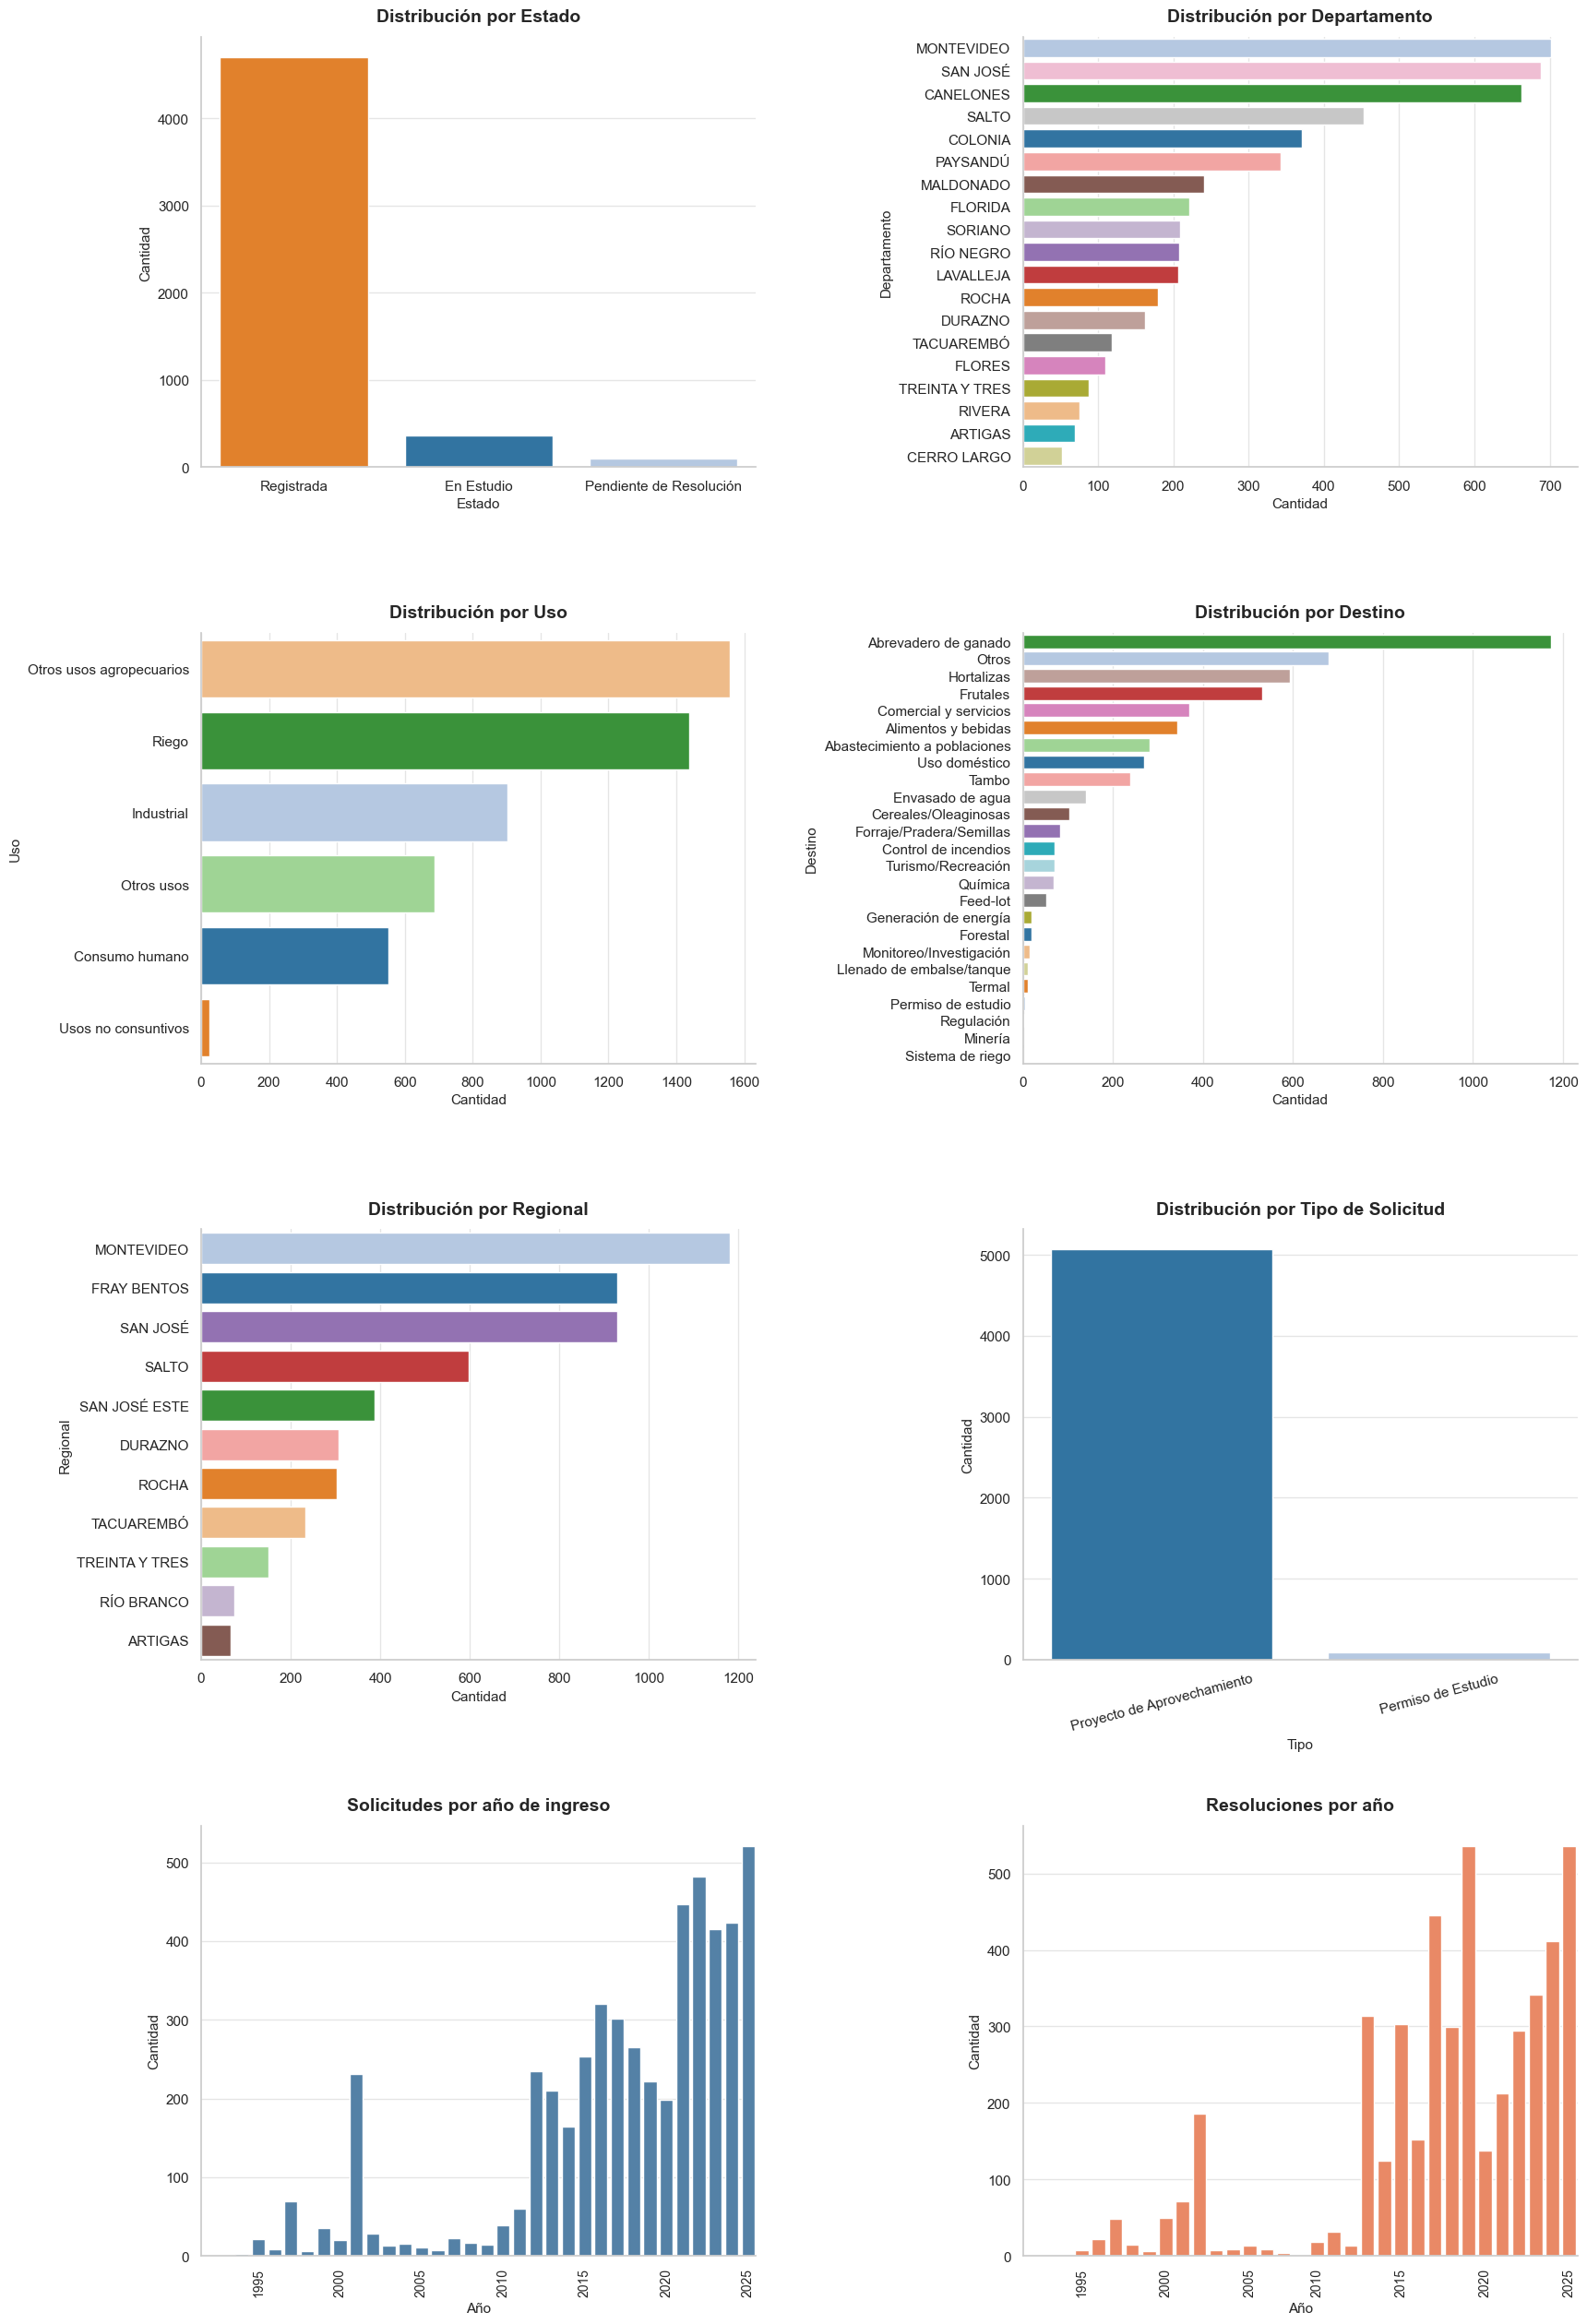

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
paleta = "tab20"

# Convertir Fecha de Solicitud a datetime si no se hizo antes
df_limpio["Fecha de Solicitud"] = pd.to_datetime(
    df_limpio["Fecha de Solicitud"],
    dayfirst=True,
    errors="coerce"
)

df_limpio["Anio_Solicitud"]  = df_limpio["Fecha de Solicitud"].dt.year
df_limpio["Anio_Resolucion"] = df_limpio["Fecha de Resolución"].dt.year

# Excluir 2026 por año incompleto
df_graf = df_limpio[df_limpio["Anio_Solicitud"] < 2026].copy()

# ── 4 filas x 2 columnas = 8 slots, usamos 7 ──
fig, axis = plt.subplots(4, 2, figsize=(18, 26))

# ── 1: Estado ──
sns.countplot(data=df_limpio, x="Estado", hue="Estado", legend=False,
              order=df_limpio["Estado"].value_counts().index,
              palette=paleta, ax=axis[0, 0])
axis[0, 0].set_title("Distribución por Estado", fontsize=14, pad=12, fontweight="bold")
axis[0, 0].set_xlabel("Estado", fontsize=11)
axis[0, 0].set_ylabel("Cantidad", fontsize=11)

# ── 2: Departamento ──
sns.countplot(data=df_limpio, y="Departamento", hue="Departamento", legend=False,
              order=df_limpio["Departamento"].value_counts().index,
              palette=paleta, ax=axis[0, 1])
axis[0, 1].set_title("Distribución por Departamento", fontsize=14, pad=12, fontweight="bold")
axis[0, 1].set_xlabel("Cantidad", fontsize=11)
axis[0, 1].set_ylabel("Departamento", fontsize=11)

# ── 3: Uso ──
sns.countplot(data=df_limpio, y="Uso", hue="Uso", legend=False,
              order=df_limpio["Uso"].value_counts().index,
              palette=paleta, ax=axis[1, 0])
axis[1, 0].set_title("Distribución por Uso", fontsize=14, pad=12, fontweight="bold")
axis[1, 0].set_xlabel("Cantidad", fontsize=11)
axis[1, 0].set_ylabel("Uso", fontsize=11)

# ── 4: Destino ──
sns.countplot(data=df_limpio, y="Destino", hue="Destino", legend=False,
              order=df_limpio["Destino"].value_counts().index,
              palette=paleta, ax=axis[1, 1])
axis[1, 1].set_title("Distribución por Destino", fontsize=14, pad=12, fontweight="bold")
axis[1, 1].set_xlabel("Cantidad", fontsize=11)
axis[1, 1].set_ylabel("Destino", fontsize=11)

# ── 5: Regional ──
sns.countplot(data=df_limpio, y="Regional", hue="Regional", legend=False,
              order=df_limpio["Regional"].value_counts().index,
              palette=paleta, ax=axis[2, 0])
axis[2, 0].set_title("Distribución por Regional", fontsize=14, pad=12, fontweight="bold")
axis[2, 0].set_xlabel("Cantidad", fontsize=11)
axis[2, 0].set_ylabel("Regional", fontsize=11)

# ── 6: Tipo de Solicitud ──
sns.countplot(data=df_limpio, x="Tipo de Solicitud", hue="Tipo de Solicitud", legend=False,
              order=df_limpio["Tipo de Solicitud"].value_counts().index,
              palette=paleta, ax=axis[2, 1])
axis[2, 1].set_title("Distribución por Tipo de Solicitud", fontsize=14, pad=12, fontweight="bold")
axis[2, 1].set_xlabel("Tipo", fontsize=11)
axis[2, 1].set_ylabel("Cantidad", fontsize=11)
axis[2, 1].tick_params(axis="x", rotation=15)

# ── 7: Año de Solicitud ──
sol_anual = (df_graf.groupby("Anio_Solicitud")
             .size().reset_index(name="Cantidad"))
anios_sol = sorted(sol_anual["Anio_Solicitud"].unique())
ticks_sol  = [a for a in anios_sol if a % 5 == 0]

sns.barplot(data=sol_anual, x="Anio_Solicitud", y="Cantidad",
            color="steelblue", edgecolor="white", ax=axis[3, 0])
axis[3, 0].set_title("Solicitudes por año de ingreso", fontsize=14, pad=12, fontweight="bold")
axis[3, 0].set_xlabel("Año", fontsize=11)
axis[3, 0].set_ylabel("Cantidad", fontsize=11)
# Mostrar solo múltiplos de 5 en el eje x
tick_positions = [i for i, a in enumerate(anios_sol) if a % 5 == 0]
axis[3, 0].set_xticks(tick_positions)
axis[3, 0].set_xticklabels([str(int(a)) for a in ticks_sol], rotation=90, fontsize=10)

# ── 8: Año de Resolución ──
res_anual = (df_limpio[df_limpio["Anio_Resolucion"] < 2026]
             .groupby("Anio_Resolucion")
             .size().reset_index(name="Cantidad"))
anios_res = sorted(res_anual["Anio_Resolucion"].unique())
ticks_res  = [a for a in anios_res if a % 5 == 0]

sns.barplot(data=res_anual, x="Anio_Resolucion", y="Cantidad",
            color="coral", edgecolor="white", ax=axis[3, 1])
axis[3, 1].set_title("Resoluciones por año", fontsize=14, pad=12, fontweight="bold")
axis[3, 1].set_xlabel("Año", fontsize=11)
axis[3, 1].set_ylabel("Cantidad", fontsize=11)
tick_positions_res = [i for i, a in enumerate(anios_res) if a % 5 == 0]
axis[3, 1].set_xticks(tick_positions_res)
axis[3, 1].set_xticklabels([str(int(a)) for a in ticks_res], rotation=90, fontsize=10)

sns.despine()
plt.tight_layout(pad=3.0)
plt.show()

#### Análisis de Variables Univariante Numéricas

Una **variable numérica** es un tipo de variable que puede tomar valores numéricos (enteros, fracciones, decimales, negativos, etc.) en un rango infinito.

### Análisis días de trámite

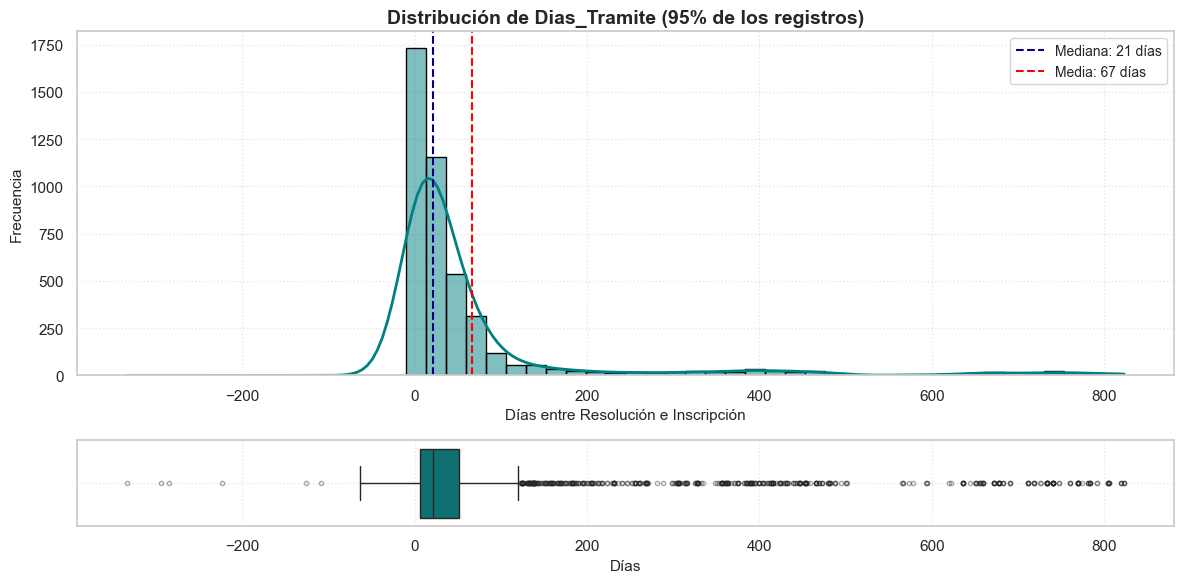

Nota: se excluyeron 233 registros con más de 830 días para mejorar la visualización.


In [44]:
# Distribución de Dias_Tramite (variable objetivo)
# Se limita al percentil 95 para visualización (outliers extremos distorsionan el gráfico)
limite_viz = df_limpio["Dias_Tramite"].quantile(0.95)
datos_viz = df_limpio[df_limpio["Dias_Tramite"] <= limite_viz]["Dias_Tramite"]

fig, axis = plt.subplots(2, 1, figsize=(12, 6),
                         gridspec_kw={"height_ratios": [4, 1]})

sns.histplot(datos_viz, bins=50, color="teal",
             edgecolor="black", kde=True,
             line_kws={"color": "coral", "linewidth": 2},
             ax=axis[0])

axis[0].set_title(
    "Distribución de Dias_Tramite (95% de los registros)",
    fontsize=14, fontweight="bold"
)
axis[0].set_xlabel("Días entre Resolución e Inscripción", fontsize=11)
axis[0].set_ylabel("Frecuencia", fontsize=11)
axis[0].axvline(datos_viz.median(), color="navy", linestyle="--", linewidth=1.5,
                label=f"Mediana: {datos_viz.median():.0f} días")
axis[0].axvline(datos_viz.mean(), color="red", linestyle="--", linewidth=1.5,
                label=f"Media: {datos_viz.mean():.0f} días")
axis[0].legend(fontsize=10)
axis[0].grid(True, linestyle=":", alpha=0.5)

sns.boxplot(x=datos_viz, color="teal", ax=axis[1],
            flierprops=dict(marker="o", markersize=3, alpha=0.4))
axis[1].set_xlabel("Días", fontsize=11)
axis[1].grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Nota: se excluyeron {(df_limpio['Dias_Tramite'] > limite_viz).sum()} "
      f"registros con más de {limite_viz:.0f} días para mejorar la visualización.")

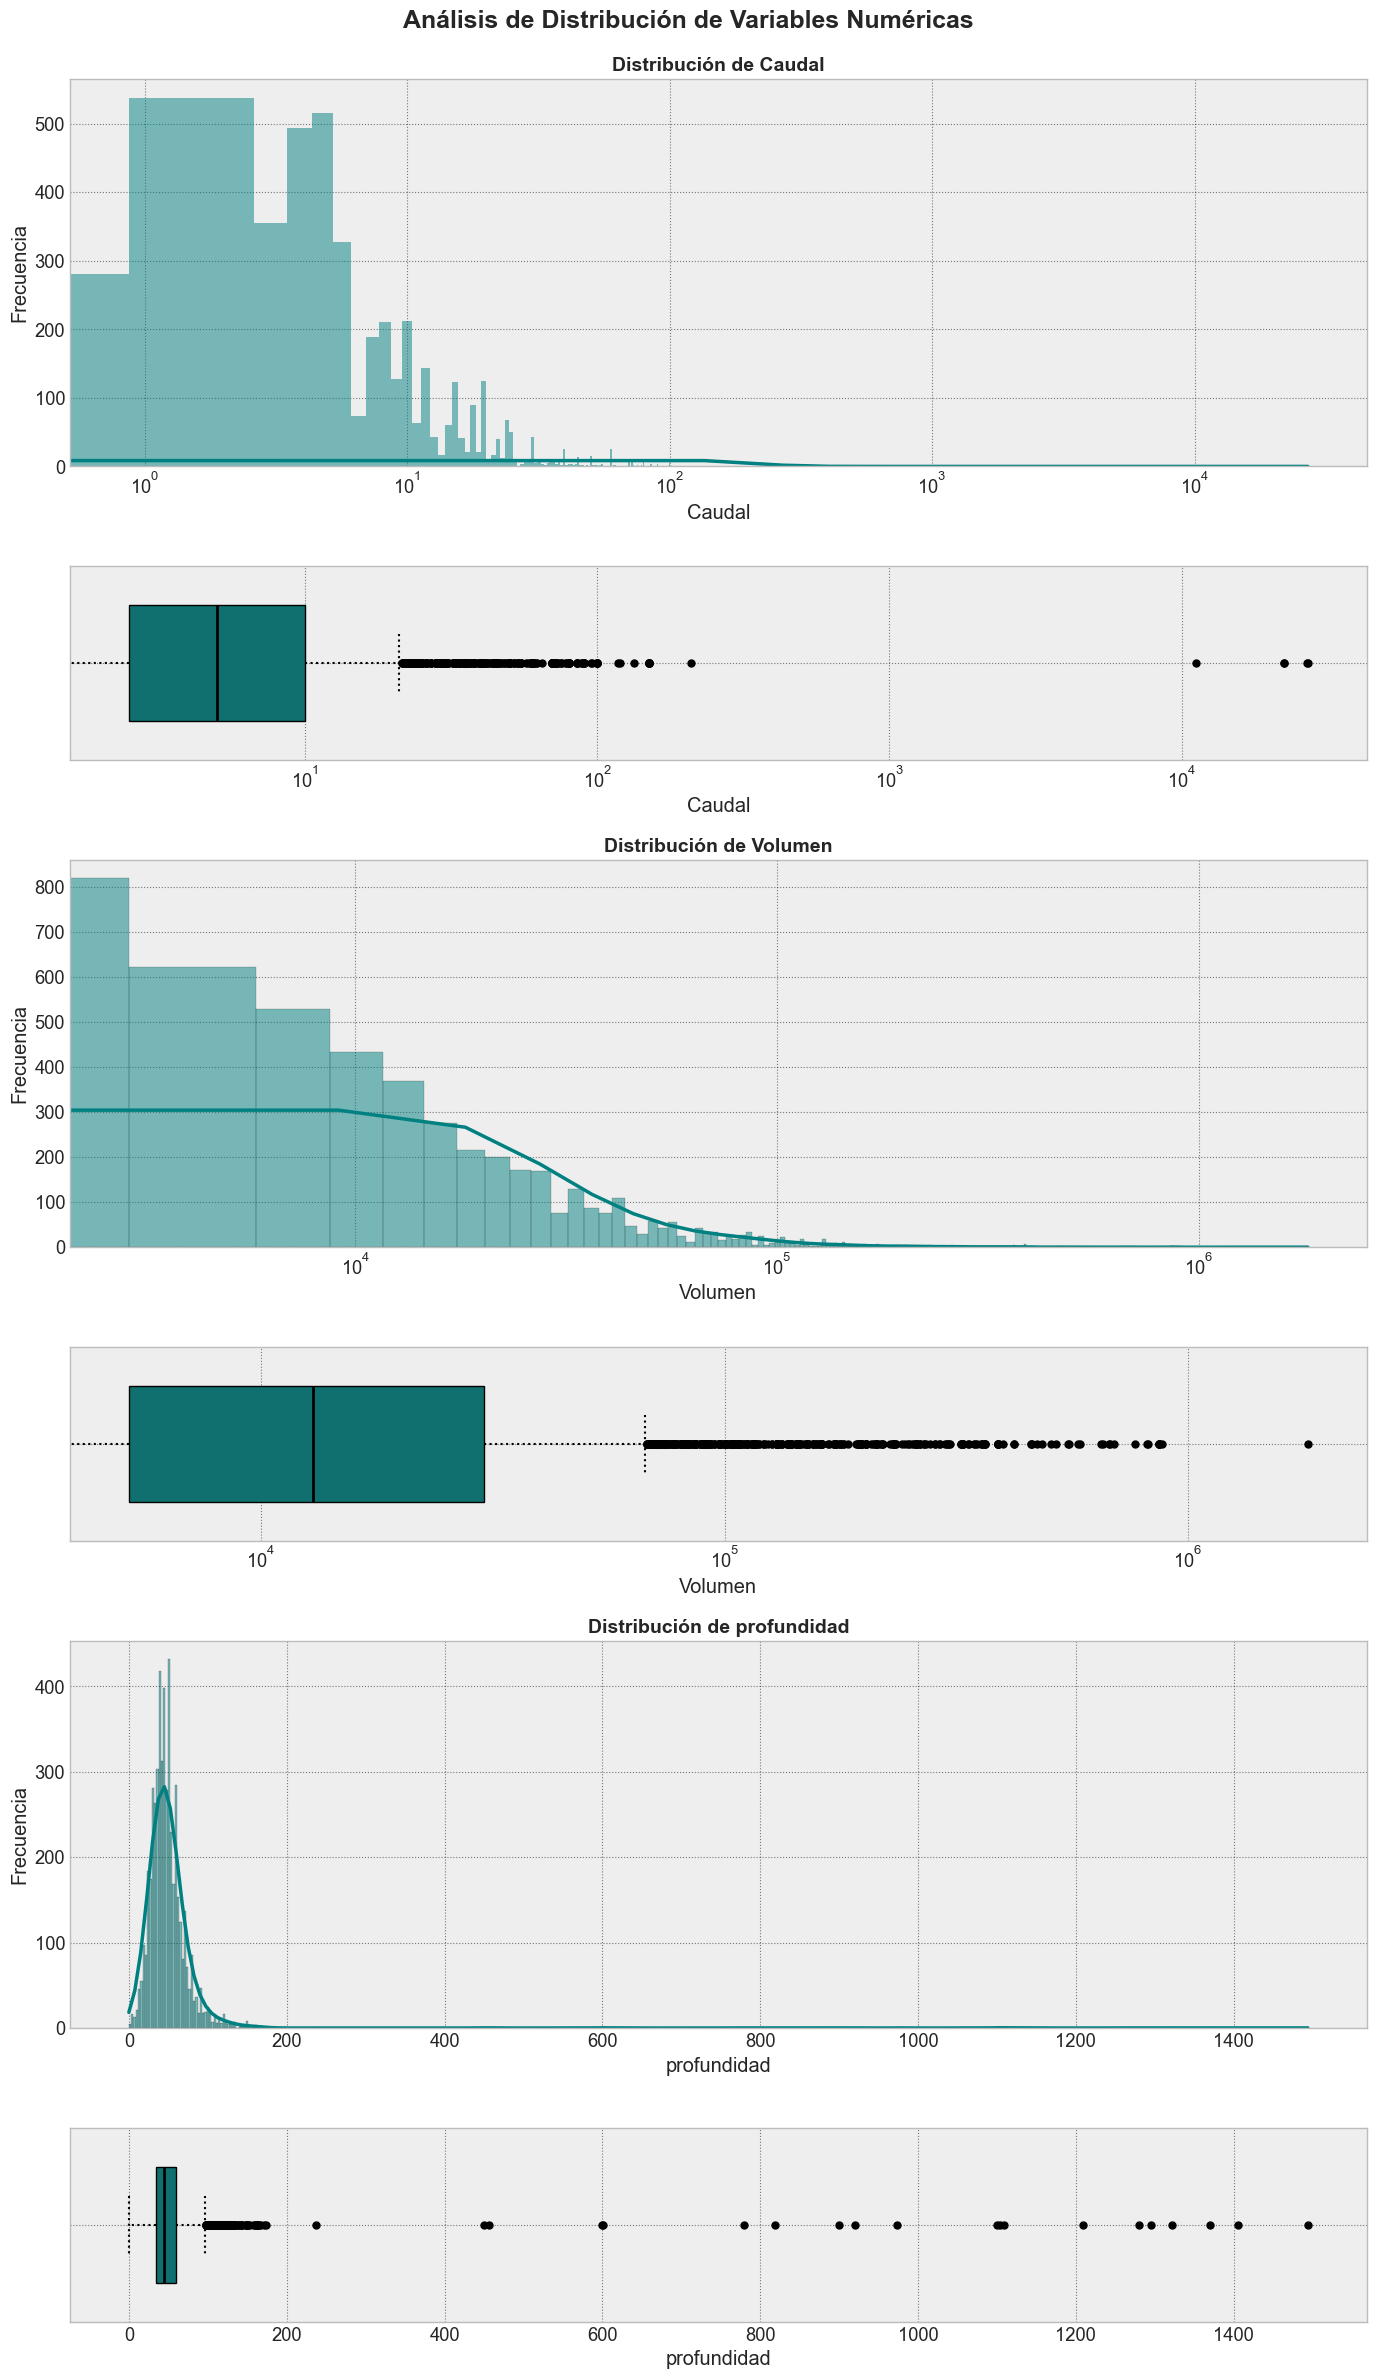

In [166]:

# Configuración de estilos base
plt.style.use("bmh")
sns.set_context("paper", font_scale=1.5)

# Variables a analizar
variables = [
    "Caudal",
    "Volumen",
    "profundidad",
]

# Variables propensas a asimetría hidráulica alta que requieren escala logarítmica
variables_log = ["Caudal", "Volumen"]

# Inicialización de la matriz de gráficos
fig, axis = plt.subplots(
    len(variables) * 2,
    1,
    figsize=(14, 24),
    gridspec_kw={"height_ratios": [4, 2] * len(variables)},
)

for i, var in enumerate(variables):
    # Índices para mapear los subplots correspondientes
    ax_hist = axis[2 * i]
    ax_box = axis[2 * i + 1]

    # ---------------------------------------------------------
    # 1. HISTOGRAMA
    # ---------------------------------------------------------
    sns.histplot(
        data=df_limpio,
        x=var,
        bins="fd",  # Regla de Estimador Freedman-Diaconis para el ancho de bins
        color="teal",
        edgecolor="black",
        kde=True,
        line_kws={"color": "aqua", "linewidth": 2.5},
        ax=ax_hist,
    )

    ax_hist.set_title(
        f"Distribución de {var}", fontsize=14, fontweight="bold"
    )
    ax_hist.set_ylabel("Frecuencia")

    # Configuración de grilla
    ax_hist.grid(True, color="black", linestyle=":", linewidth=0.8, alpha=0.5)
    ax_hist.set_axisbelow(True)

    # ---------------------------------------------------------
    # 2. BOXPLOT
    # ---------------------------------------------------------
    sns.boxplot(
        data=df_limpio,
        x=var,
        color="teal",
        width=0.6,
        ax=ax_box,
        boxprops=dict(edgecolor="black"),
        whiskerprops=dict(color="black", linestyle=":", linewidth=1.5),
        capprops=dict(color="black", linestyle=":", linewidth=1.5),
        medianprops=dict(color="black", linewidth=2),
        flierprops=dict(
            marker="o",
            markerfacecolor="black",
            markeredgecolor="black",
            markersize=5,
        ),
    )

    # Configuración de grilla
    ax_box.grid(True, color="black", linestyle=":", linewidth=0.8, alpha=0.5)
    ax_box.set_axisbelow(True)

    # ---------------------------------------------------------
    # 3. ESCALAS Y FORMATEO DE EJES (Manejo Dinámico)
    # ---------------------------------------------------------
    if var in variables_log:
        # Aplicación de escala logarítmica
        ax_hist.set_xscale("log")
        ax_box.set_xscale("log")



# Título principal institucional del reporte gráfico
fig.suptitle(
    "Análisis de Distribución de Variables Numéricas",
    fontsize=18,
    fontweight="bold",
    y=0.992,
)

plt.tight_layout()
plt.show()

### Análisis de Variables Multivariante

Tras analizar las características una a una, es momento de analizarlas en relación con la predictora y con ellas mismas, para sacar conclusiones más claras acerca de sus relaciones y poder tomar decisiones sobre su procesamiento.

Así, si quisiéramos eliminar una variable debido a una alta cantidad de valores nulos o ciertos outliers, es necesario antes aplicar este proceso para asegurar que la eliminación de ciertos valores no son críticos para la supervivencia de un pasajero.

Por ejemplo, la variable `.....` tiene muchos valores nulos, y tendríamos que asegurar que no hay relación entre ella y `....` antes de eliminarla, ya que quizá pudiera ser muy significativa e importante para el modelo y su presencia podría decantar la predicción.

## Días Trámite - Regional

C:\Users\Georgina\AppData\Local\Temp\ipykernel_4640\3880865806.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x="Dias_Tramite", y="Regional",


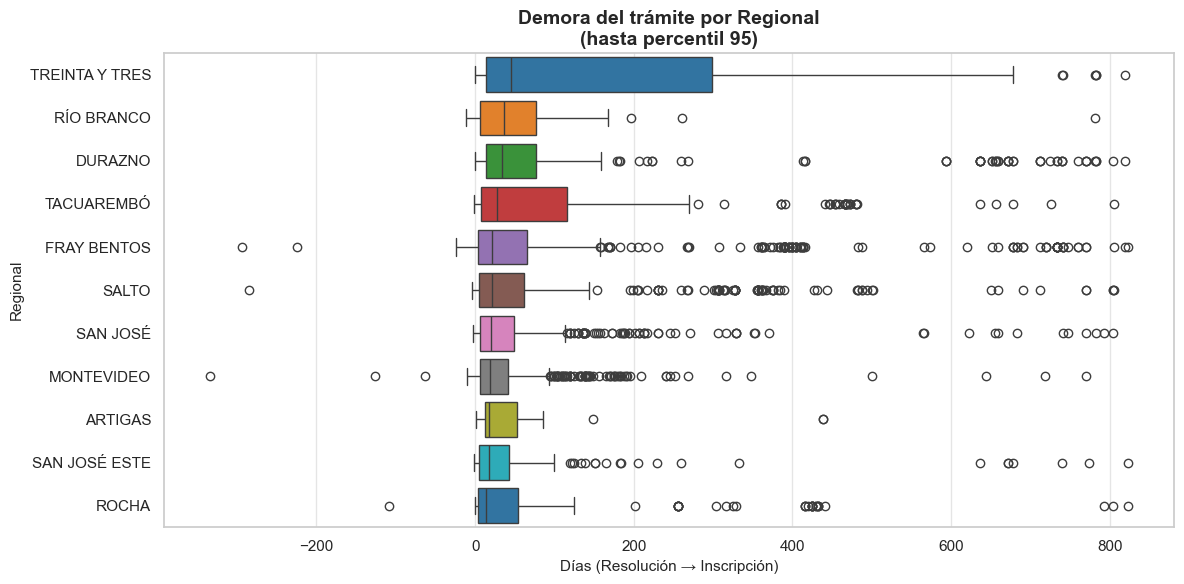

In [83]:
# Boxplot: Dias_Tramite por Regional
limite = df_limpio["Dias_Tramite"].quantile(0.95)
df_box = df_limpio[df_limpio["Dias_Tramite"] <= limite]

orden = (df_box.groupby("Regional")["Dias_Tramite"]
         .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_box, x="Dias_Tramite", y="Regional",
            order=orden, palette="tab10", ax=ax)
ax.set_title("Demora del trámite por Regional\n(hasta percentil 95)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Días (Resolución → Inscripción)", fontsize=11)
ax.set_ylabel("Regional", fontsize=11)
plt.tight_layout()
plt.show()

## Días Trámite - Uso

C:\Users\Georgina\AppData\Local\Temp\ipykernel_4640\3959304167.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x="Dias_Tramite", y="Uso",


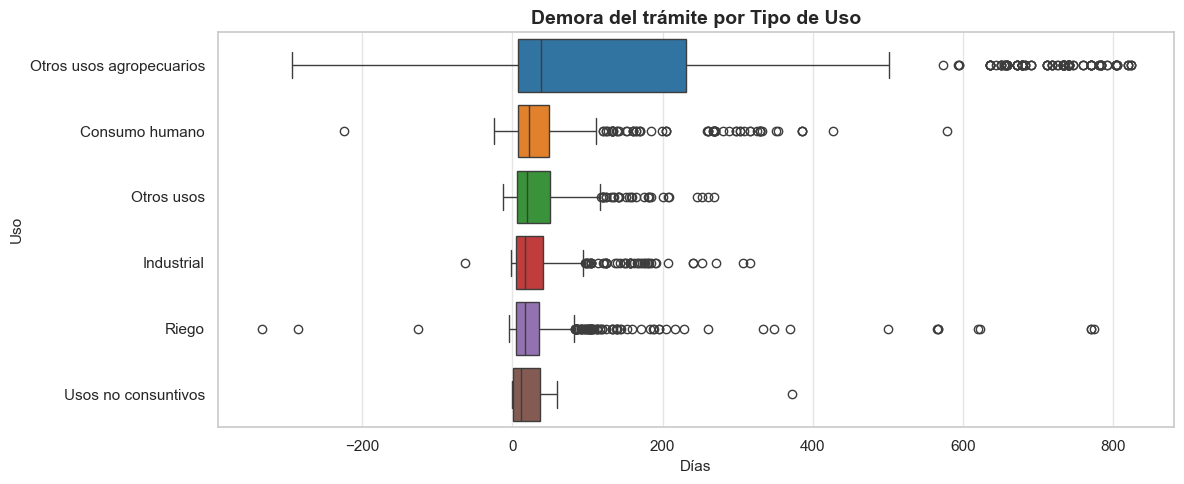

In [79]:
orden_uso = (df_box.groupby("Uso")["Dias_Tramite"]
             .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_box, x="Dias_Tramite", y="Uso",
            order=orden_uso, palette="tab10", ax=ax)
ax.set_title("Demora del trámite por Tipo de Uso",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Días", fontsize=11)
ax.set_ylabel("Uso", fontsize=11)
plt.tight_layout()
plt.show()

## Evolución del trámite promedio por año

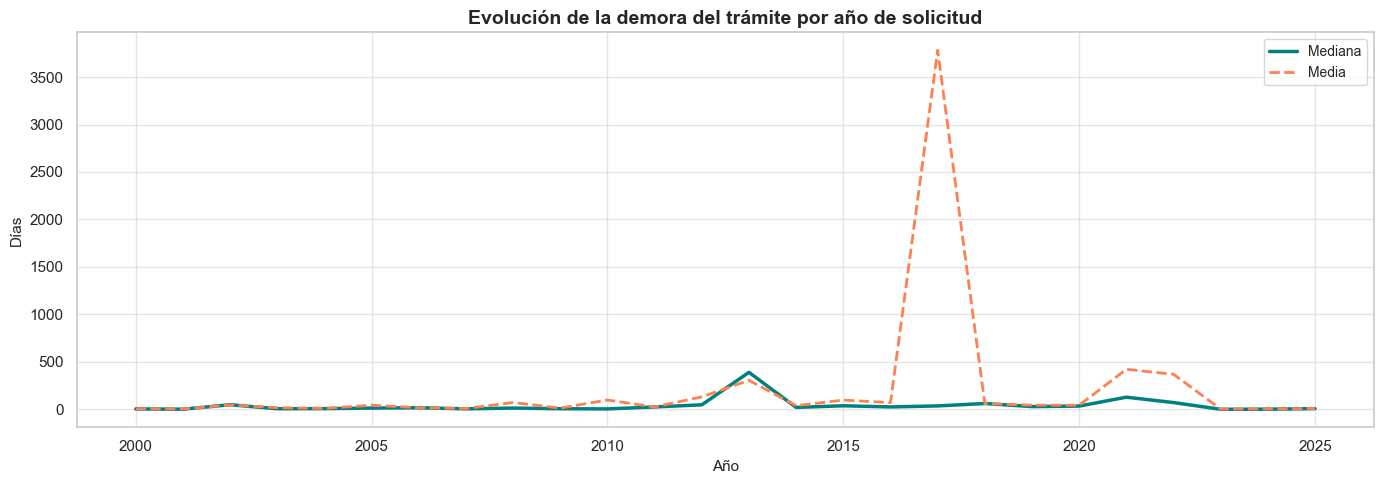

In [80]:
evol = (df_limpio[df_limpio["Anio_Solicitud"].between(2000, 2025)]
        .groupby("Anio_Solicitud")["Dias_Tramite"]
        .agg(["median", "mean"])
        .reset_index())

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=evol, x="Anio_Solicitud", y="median",
             color="teal", linewidth=2.5, label="Mediana", ax=ax)
sns.lineplot(data=evol, x="Anio_Solicitud", y="mean",
             color="coral", linewidth=2, linestyle="--", label="Media", ax=ax)
ax.set_title("Evolución de la demora del trámite por año de solicitud",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Año", fontsize=11)
ax.set_ylabel("Días", fontsize=11)
ax.set_xticks(range(2000, 2026, 5))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

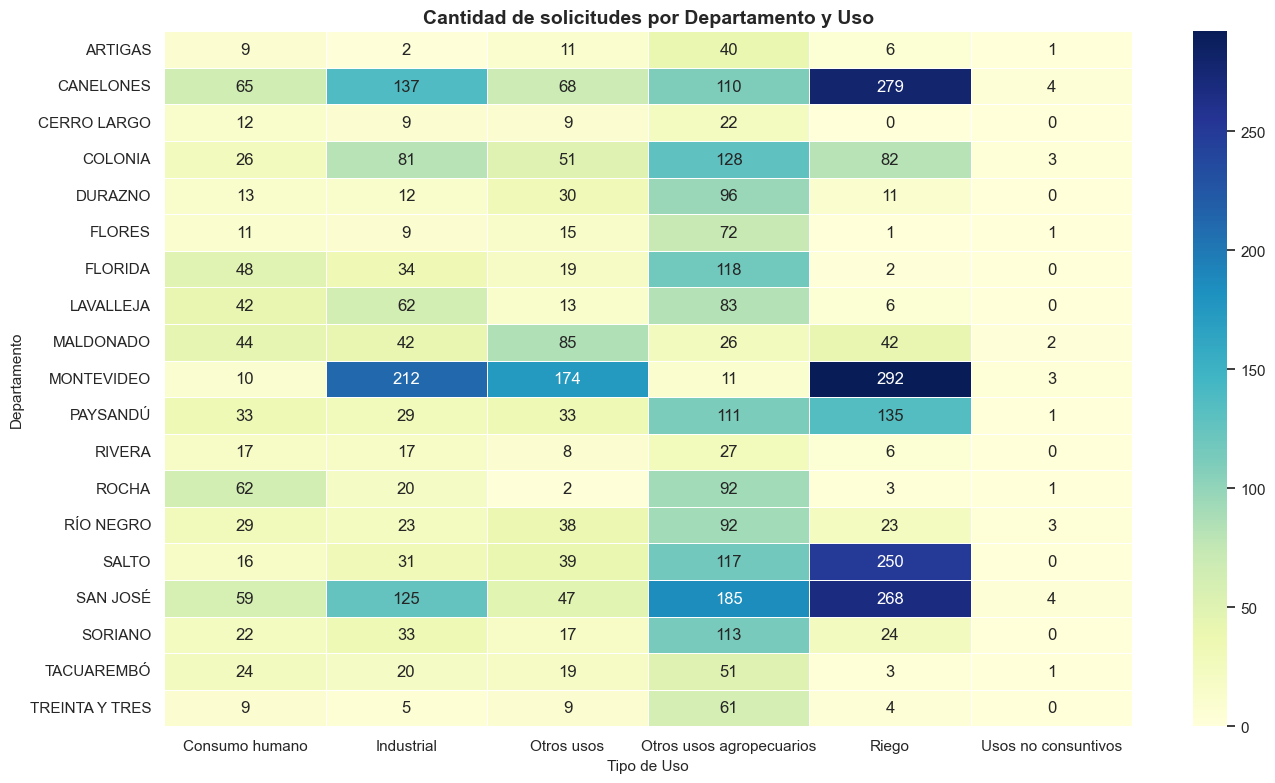

In [81]:
pivot = (df_limpio.groupby(["Departamento", "Uso"])
         .size().unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu",
            linewidths=0.5, ax=ax)
ax.set_title("Cantidad de solicitudes por Departamento y Uso",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Tipo de Uso", fontsize=11)
ax.set_ylabel("Departamento", fontsize=11)
plt.tight_layout()
plt.show()

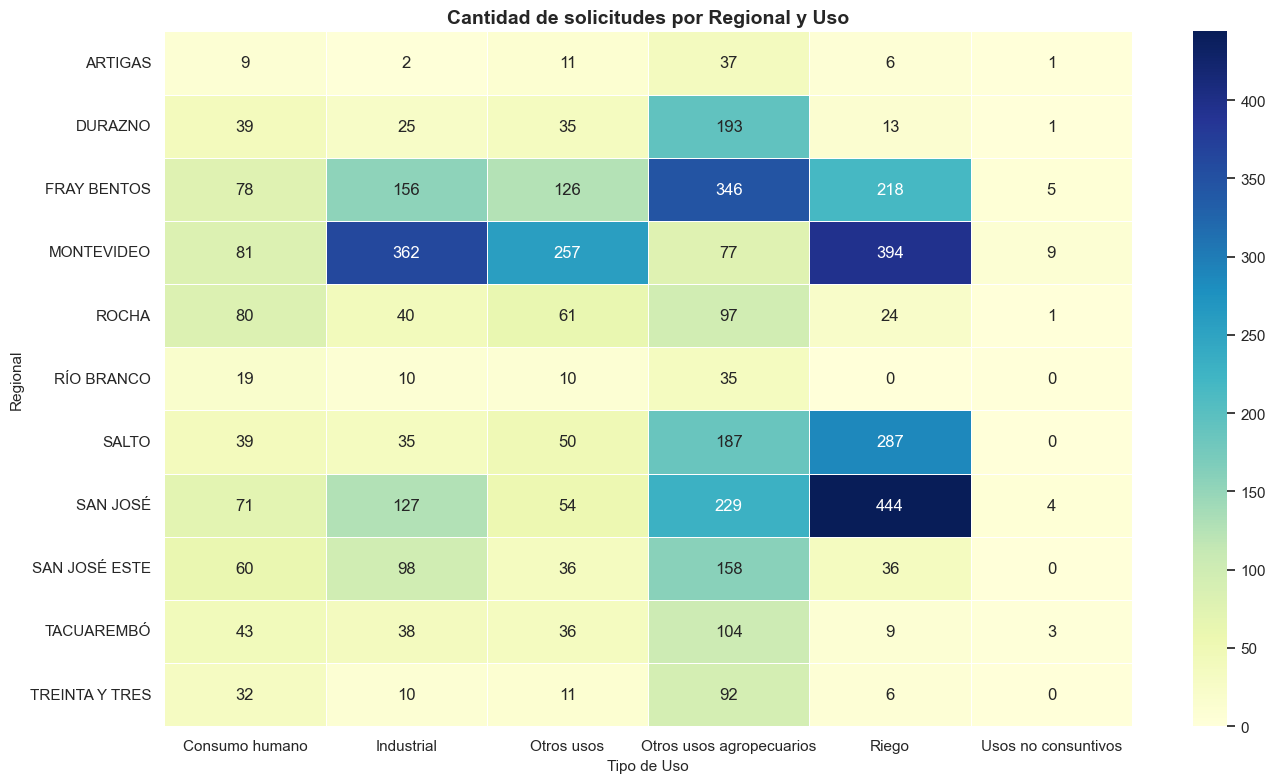

In [87]:
pivot = (df_limpio.groupby(["Regional", "Uso"])
         .size().unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu",
            linewidths=0.5, ax=ax)
ax.set_title("Cantidad de solicitudes por Regional y Uso",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Tipo de Uso", fontsize=11)
ax.set_ylabel("Regional", fontsize=11)
plt.tight_layout()
plt.show()

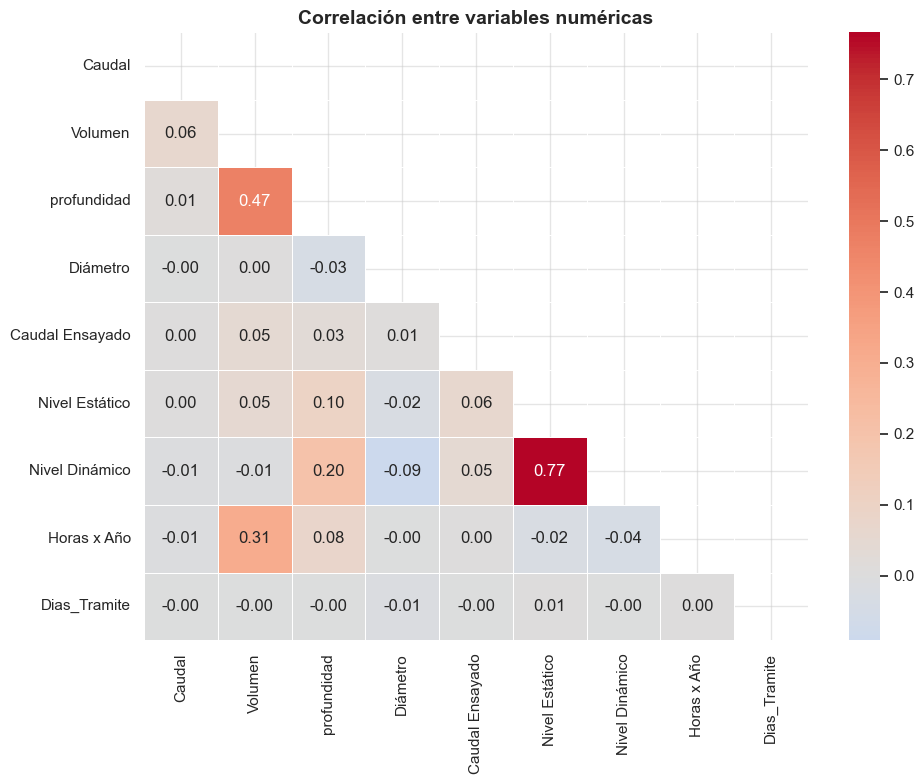

In [82]:
nums = ["Caudal", "Volumen", "profundidad", "Diámetro",
        "Caudal Ensayado", "Nivel Estático", "Nivel Dinámico",
        "Horas x Año", "Dias_Tramite"]

fig, ax = plt.subplots(figsize=(10, 8))
corr = df_limpio[nums].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax)
ax.set_title("Correlación entre variables numéricas",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

> ##### Observaciones
>
> - Las variables numéricas del dataset presentan correlaciones bajas entre sí y con `Dias_Tramite`,
>   lo que indica que **la demora del trámite no depende linealmente de las características técnicas
>   del pozo** (caudal, volumen, profundidad).
> - Se observa una correlación moderada entre `Nivel Estático` y `Nivel Dinámico` (esperada,
>   ya que ambas miden el nivel de agua del mismo acuífero en distintas condiciones).
> - `Caudal` y `Volumen` presentan cierta correlación positiva, lo cual es consistente dado que
>   el volumen se calcula a partir del caudal.
> - La ausencia de correlación lineal con `Dias_Tramite` sugiere que los factores determinantes
>   de la demora son **administrativos y categóricos** (regional, tipo de uso), no técnicos.


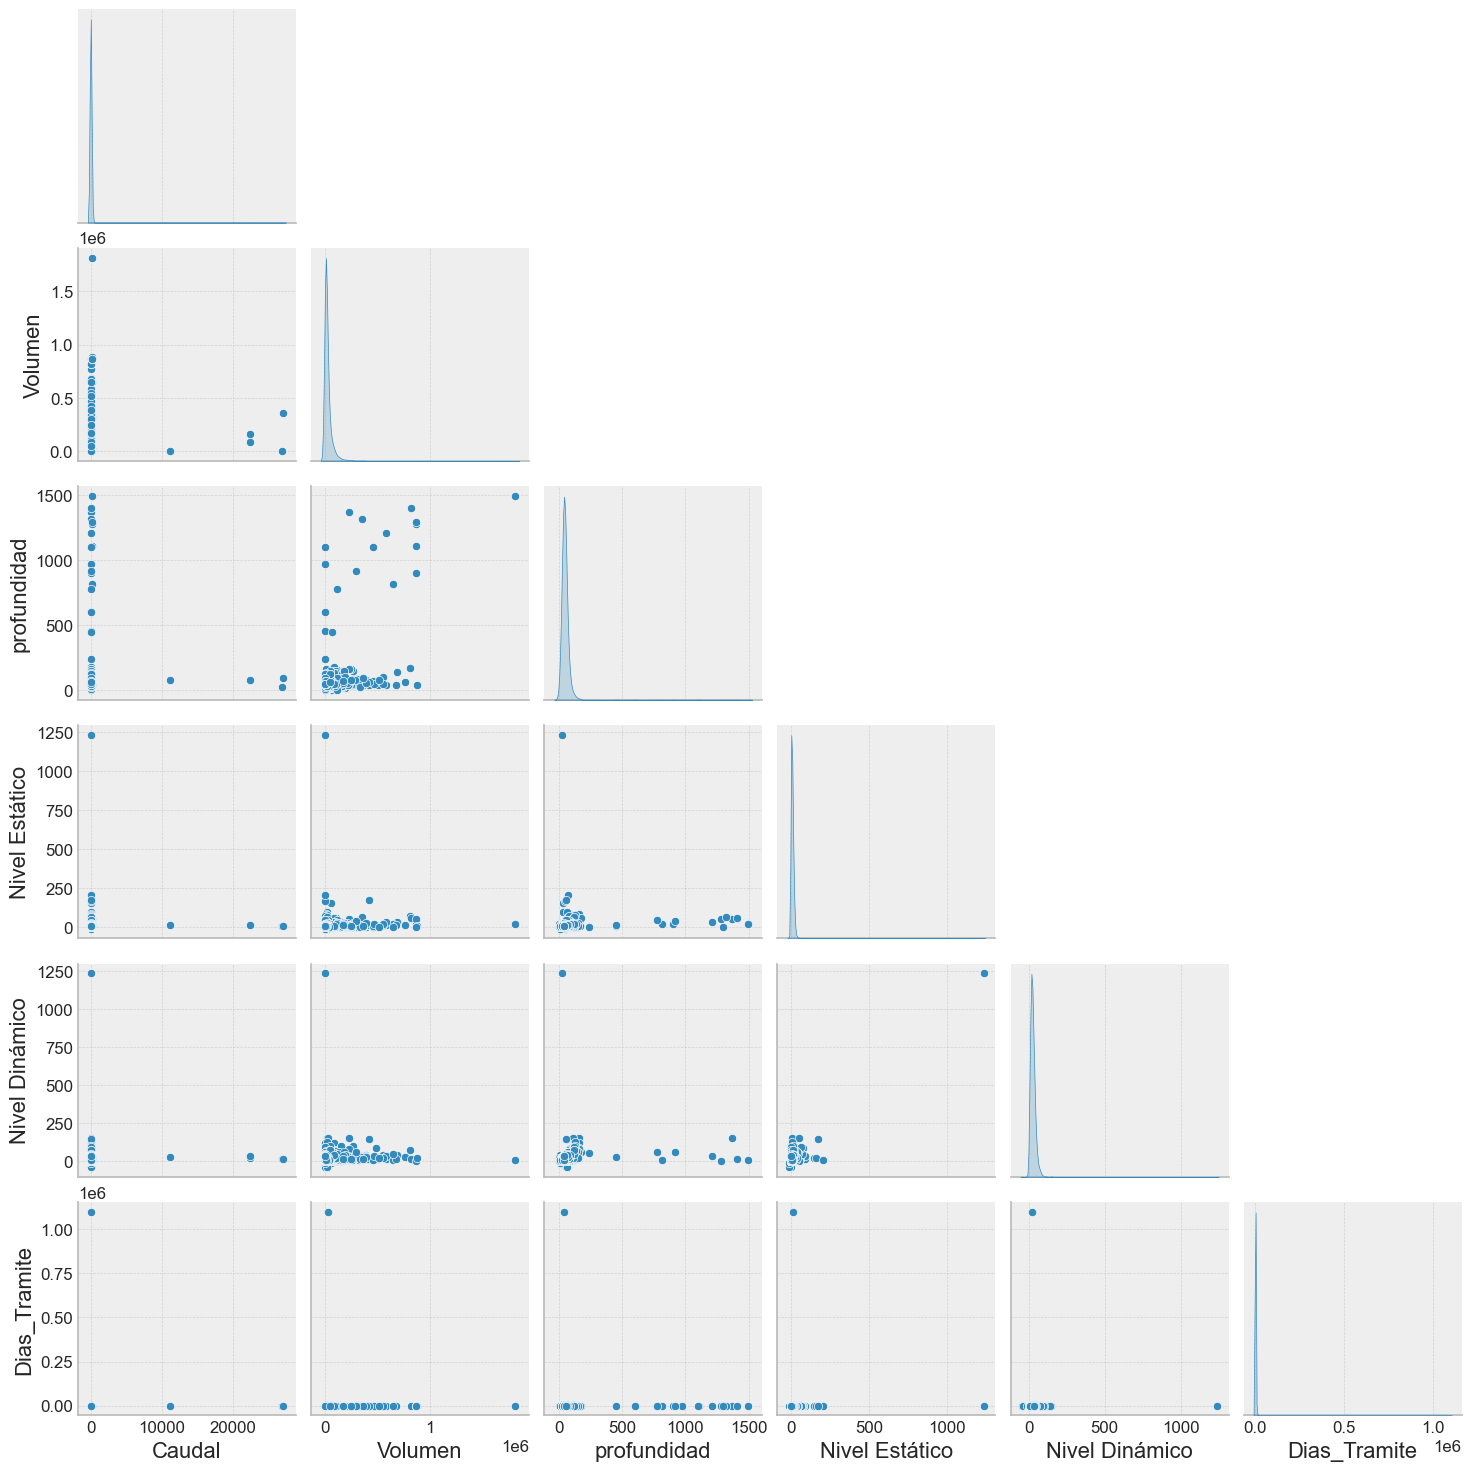

In [109]:
variables = [
    "Caudal",
    "Volumen",
    "profundidad",
    "Nivel Estático",
    "Nivel Dinámico",
    "Dias_Tramite"
]

sns.pairplot(
    data=df_limpio[variables],
    corner=True,
    diag_kind="kde"
)

plt.show()

In [113]:
sns.pairplot(df_std, corner=True)

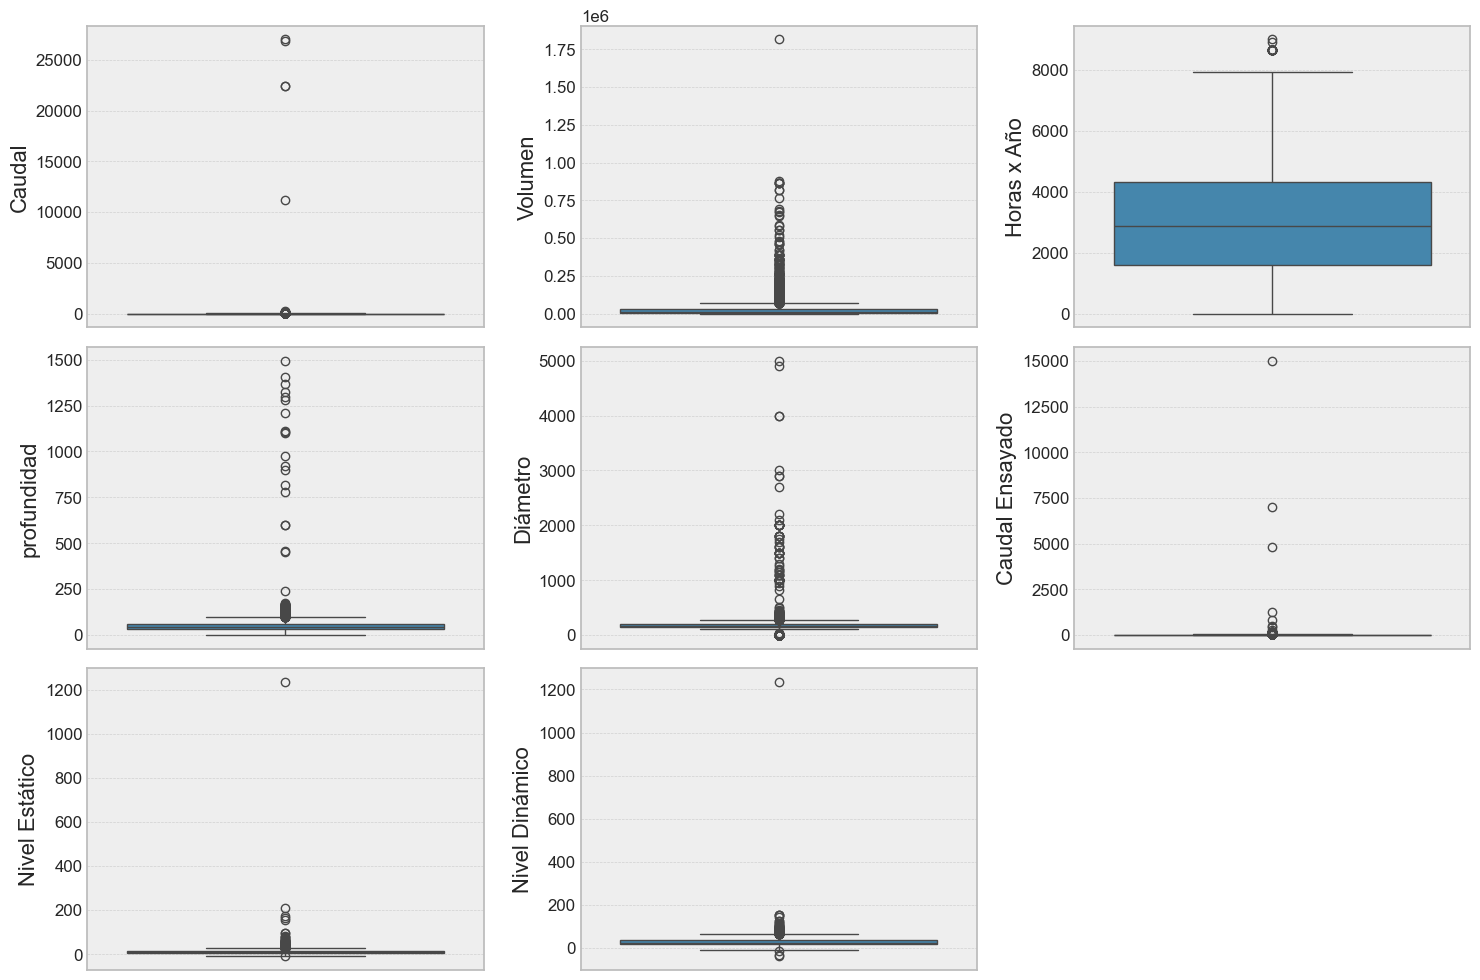

In [116]:
fig, axis = plt.subplots(3, 3, figsize=(15, 10))

sns.boxplot(ax=axis[0, 0], data=df_limpio, y="Caudal")
sns.boxplot(ax=axis[0, 1], data=df_limpio, y="Volumen")
sns.boxplot(ax=axis[0, 2], data=df_limpio, y="Horas x Año")

sns.boxplot(ax=axis[1, 0], data=df_limpio, y="profundidad")
sns.boxplot(ax=axis[1, 1], data=df_limpio, y="Diámetro")
sns.boxplot(ax=axis[1, 2], data=df_limpio, y="Caudal Ensayado")

sns.boxplot(ax=axis[2, 0], data=df_limpio, y="Nivel Estático")
sns.boxplot(ax=axis[2, 1], data=df_limpio, y="Nivel Dinámico")

fig.delaxes(axis[2, 2])

plt.tight_layout()
plt.show()

## Paso 6: Ingeniería de características

In [111]:
outliers = df_limpio[
    (df_limpio["Caudal"] < lower_limit) |
    (df_limpio["Caudal"] > upper_limit)
]

print("Cantidad de outliers:", len(outliers))

Cantidad de outliers: 484


In [112]:
variables = [
    "Caudal",
    "Volumen",
    "profundidad",
    "Caudal Ensayado"
]

for var in variables:
    q1 = df_limpio[var].quantile(0.25)
    q3 = df_limpio[var].quantile(0.75)
    iqr = q3 - q1

    lower = max(0, q1 - 1.5 * iqr)
    upper = q3 + 1.5 * iqr

    outliers = df_limpio[
        (df_limpio[var] < lower) |
        (df_limpio[var] > upper)
    ]

    print(f"{var}: {len(outliers)} outliers")

Caudal: 484 outliers
Volumen: 532 outliers
profundidad: 184 outliers
Caudal Ensayado: 350 outliers


In [113]:
print(df_limpio["Fecha de Solicitud"].dtype)
print(df_limpio["Fecha de Resolución"].dtype)

str
datetime64[s]


In [115]:
df_limpio["Fecha de Solicitud"] = pd.to_datetime(
    df_limpio["Fecha de Solicitud"],
    dayfirst=True,
    errors="coerce"
)

In [118]:
df_limpio[["Fecha de Solicitud", "Fecha de Resolución"]].dtypes

Fecha de Solicitud     datetime64[us]
Fecha de Resolución     datetime64[s]
dtype: object

In [ ]:
df_limpio["Dias_Tramite"] = (
    df_limpio["Fecha de Resolución"]
    - df_limpio["Fecha de Solicitud"]
).dt.days

In [120]:
print("Dias_Tramite" in df_limpio.columns)

False


In [121]:
print(df_limpio.columns.tolist()[-10:])

['Documento', 'Sección y localidad catastral', 'Cuencas de nivel 3', 'profundidad', 'Diámetro', 'Caudal Ensayado', 'Nivel Estático', 'Nivel Dinámico', 'Accion Solicitud', 'Tipo Resolución']


In [123]:
# Convertir fechas
df_limpio["Fecha de Solicitud"] = pd.to_datetime(
    df_limpio["Fecha de Solicitud"],
    dayfirst=True,
    errors="coerce"
)

df_limpio["Fecha de Resolución"] = pd.to_datetime(
    df_limpio["Fecha de Resolución"],
    errors="coerce"
)

# Crear target
df_limpio["Dias_Tramite"] = (
    df_limpio["Fecha de Resolución"]
    - df_limpio["Fecha de Solicitud"]
).dt.days

In [124]:
df_limpio["Dias_Tramite"].describe()

count    4698.000000
mean      166.079395
std       605.811682
min     -3463.000000
25%        33.000000
50%       109.000000
75%       232.000000
max      6284.000000
Name: Dias_Tramite, dtype: float64

In [125]:
df_limpio.columns.tolist()

['Tipo de Solicitud',
 'Nro. GEX',
 'Fecha Vencimiento',
 'Estado',
 'Regional',
 'Departamento',
 'Tecnicos',
 'Fecha de Solicitud',
 'Fecha de Resolución',
 'Fecha de Inscripción',
 'Caudal',
 'Volumen',
 'Uso',
 'Destino',
 'Latitud',
 'Longitud',
 'Mes Inicio',
 'Mes Final',
 'Horas x Año',
 'Depto.-Padrón',
 'Tipo de Obra',
 'Id Solicitud',
 'Codigo Cuencas de nivel 5',
 'Documento',
 'Sección y localidad catastral',
 'Cuencas de nivel 3',
 'profundidad',
 'Diámetro',
 'Caudal Ensayado',
 'Nivel Estático',
 'Nivel Dinámico',
 'Accion Solicitud',
 'Tipo Resolución',
 'Dias_Tramite']

## Paso 6: Ingeniería de características

### Primer Enfoque: Realizar cambios antes de hacer el split de datos

## Paso 7: Split de los datos

### Primer enfoque: transformación antes de la división

En este enfoque se realizaron las transformaciones necesarias sobre el conjunto de datos completo antes de dividirlo en conjuntos de entrenamiento y prueba.

Las variables numéricas fueron escaladas mediante estandarización y las variables categóricas fueron codificadas utilizando variables indicadoras (*dummy variables*). Posteriormente, el conjunto de datos fue dividido en un 80% para entrenamiento y un 20% para prueba.

Si bien este procedimiento garantiza que todos los datos sean transformados de manera uniforme, presenta el riesgo de fuga de información (*data leakage*), ya que los parámetros de transformación se calculan utilizando la totalidad de los registros, incluidos aquellos que posteriormente formarán parte del conjunto de prueba.

### Segundo Enfoque: Realizar cambios después de hacer el split de datos.

En este enfoque:

- Primero se divide el dataset en conjuntos de entrenamiento y prueba
- Luego se procesa cada conjunto por separado (escalando/codificando) usando los parámetros que se calcularon sobre el conjunto de entrenamiento.

Ventaja:

Refleja mejor el escenario del mundo real donde el modelo no tiene acceso a los datos de prueba durante el entrenamiento. Esto asegura una evaluación justa del modelo en el conjunto de prueba.

Desventaja:

Puede haber ligeras diferencias en el procesamiento entre los conjuntos de entrenamiento y prueba, ya que los parámetros se basan solo en el conjunto de entrenamiento. Sin embargo, esto generalmente no es un problema si el conjunto de datos es lo suficientemente grande y representativo.

In [61]:
df.shape

(7698, 43)

In [127]:
df.isnull().sum()

Tipo de Solicitud                2539
Nro. GEX                         2541
Fecha Vencimiento                3013
Estado                           2539
Regional                         2541
Departamento                     2541
Tecnicos                         2556
Fecha de Solicitud               2540
Fecha de Resolución              2999
Fecha de Inscripción             3045
Caudal                           2585
Volumen                          2571
Uso                              2539
Destino                          2539
Latitud                          2540
Longitud                         2539
Mes Inicio                       2575
Mes Final                        2575
Horas x Año                      2577
Depto.-Padrón                    2553
Tipo de Obra                     2540
Id Solicitud                     2539
Codigo Cuencas de nivel 5        2546
Documento                        2540
Sección y localidad catastral    4311
Cuencas de nivel 3               2546
Curso a Util

## Paso 7: Split de los datos
Definir X e y

In [129]:
df_modelo = df_limpio.dropna(subset=["Dias_Tramite"]).copy()

In [130]:
X = df_modelo.drop(columns=["Dias_Tramite"])
y = df_modelo["Dias_Tramite"]

Primer Enfoque
Codificación

In [131]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Verificación

In [132]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3758, 33)
(940, 33)
(3758,)
(940,)


## Paso 8: Scaling & Encoding

El objetivo de este paso es preparar las variables del dataset para que puedan ser utilizadas por un modelo de Machine Learning.

Dado que el modelo buscará **predecir `Dias_Tramite`** (una variable numérica continua), se trata de un problema de **regresión**.

Para ello se realizarán dos transformaciones:
- **Scaling (Escalado):** estandarizar las variables numéricas para que tengan media 0 y desviación estándar 1.
- **Encoding (Codificación):** convertir las variables categóricas a valores numéricos que el modelo pueda interpretar.

Antes de escalar o codificar, se construye un **DataFrame de modelado** con las variables seleccionadas como predictoras y la variable objetivo.

### 8.a Selección de variables para el modelo

No todas las columnas del dataset son útiles para predecir la demora del trámite. Se descartan:
- **Identificadores únicos:** `Nro. GEX`, `Id Solicitud`, `Documento`, `Depto.-Padrón` (no aportan patrón generalizable)
- **Columnas de fecha:** ya se extrajo la información útil en `Dias_Tramite`
- **Variables con altísima cardinalidad:** `Tecnicos` (426 valores únicos), `Cuencas de nivel 3` (261), `Tipo de acuifero` (36) — dificultan la codificación y generan ruido
- **Coordenadas geográficas:** `Latitud` y `Longitud` se reservan para el mapa de Streamlit
- **`Estado` y `Tipo Resolución`:** son variables que se conocen *después* de que el trámite finaliza, por lo tanto incluirlas sería filtración de datos (*data leakage*)

Las variables **seleccionadas como predictoras** son:

| Variable | Tipo | Justificación |
|---|---|---|
| Regional | Categórica | La oficina regional puede afectar los tiempos de procesamiento |
| Departamento | Categórica | La ubicación geográfica puede influir en la carga de trabajo |
| Uso | Categórica | El tipo de uso del agua puede determinar la complejidad del trámite |
| Destino | Categórica | La finalidad específica puede requerir distinto nivel de análisis |
| Tipo de Solicitud | Categórica | Puede haber diferencias entre tipos de trámite |
| Accion Solicitud | Categórica | El tipo de acción puede tener distinto tiempo de procesamiento |
| Caudal | Numérica | Mayor caudal puede implicar mayor complejidad técnica |
| Volumen | Numérica | Relacionado con el impacto ambiental del uso |
| profundidad | Numérica | Característica técnica del pozo |
| Diámetro | Numérica | Característica técnica del pozo |
| Caudal Ensayado | Numérica | Resultado del ensayo de bombeo |
| Nivel Estático | Numérica | Característica del acuífero |
| Nivel Dinámico | Numérica | Característica del acuífero |
| Horas x Año | Numérica | Intensidad de uso del recurso hídrico |
| Mes Inicio | Numérica | Estacionalidad del uso |
| Mes Final | Numérica | Estacionalidad del uso |

In [118]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import f_regression, SelectKBest
import pickle
import json

# Columnas seleccionadas como predictoras
cols_categoricas = [
    "Regional",
    "Departamento",
    "Uso",
    "Destino",
    "Tipo de Solicitud",
    "Accion Solicitud"
]

cols_numericas = [
    "Caudal",
    "Volumen",
    "profundidad",
    "Diámetro",
    "Caudal Ensayado",
    "Nivel Estático",
    "Nivel Dinámico",
    "Horas x Año",
    "Mes Inicio",
    "Mes Final"
]

target = "Dias_Tramite"

# Construir el DataFrame de modelado
# Solo filas con target válido y no negativo (negativos = error de fechas)
df_modelo = df_limpio[cols_categoricas + cols_numericas + [target]].copy()
df_modelo = df_modelo.dropna(subset=[target])
df_modelo = df_modelo[df_modelo[target] >= 0]

print(f"Registros disponibles para modelado: {df_modelo.shape[0]}")
print(f"Variables predictoras: {len(cols_categoricas) + len(cols_numericas)}")
print(f"Variable objetivo: {target}")


Registros disponibles para modelado: 4637
Variables predictoras: 16
Variable objetivo: Dias_Tramite


### 8.b Imputación de valores faltantes

Antes de escalar y codificar, es necesario tratar los valores nulos restantes en las variables predictoras:
- Las variables **numéricas** se imputan con la **mediana** (más robusta que la media ante outliers, que son frecuentes en datos hidráulicos)
- Las variables **categóricas** no presentan nulos en las columnas seleccionadas

In [119]:
# Verificar nulos antes de imputar
print("Nulos por columna antes de imputar:")
print(df_modelo[cols_numericas].isnull().sum().sort_values(ascending=False))

Nulos por columna antes de imputar:
Nivel Dinámico     406
Nivel Estático     286
Caudal Ensayado    175
Diámetro            61
Caudal              42
profundidad         41
Horas x Año         34
Mes Inicio          32
Mes Final           32
Volumen             30
dtype: int64


In [120]:
# Imputar variables numéricas con la mediana
for col in cols_numericas:
    mediana = df_modelo[col].median()
    df_modelo[col] = df_modelo[col].fillna(mediana)

# Verificar que no queden nulos
print("Nulos por columna después de imputar:")
print(df_modelo.isnull().sum().sum(), "nulos totales restantes")


Nulos por columna después de imputar:
0 nulos totales restantes


### 8.c Split previo al escalado

Siguiendo el **segundo enfoque** visto en el Paso 7 (el correcto), el escalado y la codificación se realizan **después** de dividir el dataset. Esto evita la fuga de información (*data leakage*): los parámetros del escalador se aprenden únicamente del conjunto de entrenamiento y luego se aplican al de prueba.

In [121]:
# Separar predictoras y target
X = df_modelo[cols_categoricas + cols_numericas]
y = df_modelo[target]

# Split 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train: {X_train.shape[0]} registros")
print(f"Test:  {X_test.shape[0]} registros")

Train: 3709 registros
Test:  928 registros


### 8.d Encoding de variables categóricas

Se utiliza **Label Encoding** para cada variable categórica. Esta técnica asigna un entero único a cada categoría.

Es adecuada para este caso porque:
- Las categorías tienen cardinalidad moderada (máximo 24 valores únicos)
- Se evita la explosión de columnas que generaría One-Hot Encoding

> **Importante:** el encoder se entrena solo con los datos de `X_train` y luego se aplica a `X_test`. Para valores desconocidos en test se usa `transform` de manera segura con manejo de errores.

Los encoders se guardan en disco para poder reutilizarlos en la aplicación Streamlit.

In [122]:
# Crear copias para no modificar los originales
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

# Diccionario para guardar los encoders
encoders = {}

for col in cols_categoricas:
    le = LabelEncoder()
    # Entrenar con los datos de train
    le.fit(X_train[col])
    # Aplicar a train
    X_train_enc[col] = le.transform(X_train[col])
    # Aplicar a test (valores desconocidos se reemplazan con -1)
    X_test_enc[col] = X_test[col].apply(
        lambda val: le.transform([val])[0] if val in le.classes_ else -1
    )
    encoders[col] = le

print("Encoding completado. Primeras filas de X_train codificado:")
X_train_enc[cols_categoricas].head()

Encoding completado. Primeras filas de X_train codificado:


,Regional,Departamento,Uso,Destino,Tipo de Solicitud,Accion Solicitud
6083,6,14,4,12,1,1
6382,4,8,2,16,1,3
2911,7,15,4,10,1,1
3541,3,9,1,16,1,1
6423,2,13,1,2,1,9


In [123]:
# Guardar los encoders para usarlos en Streamlit
import os
os.makedirs("../models", exist_ok=True)

with open("../models/label_encoders_dinagua.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("Encoders guardados en ../models/label_encoders_dinagua.pkl")

Encoders guardados en ../models/label_encoders_dinagua.pkl


### 8.e Scaling de variables numéricas

Se utiliza **StandardScaler** (estandarización), que transforma cada variable para que tenga **media = 0** y **desviación estándar = 1**.

Es la técnica más adecuada para este dataset porque:
- Las variables hidráulicas tienen escalas muy distintas (ej. `Volumen` en miles vs `Mes Inicio` entre 1 y 12)
- `Dias_Tramite` tiene una distribución asimétrica con outliers importantes, y la estandarización es más robusta que Min-Max en estos casos

El scaler se entrena **solo con `X_train`** y luego se aplica a ambos conjuntos.

In [124]:
# Instanciar el scaler
scaler = StandardScaler()

# Entrenar con X_train y transformar
X_train_enc[cols_numericas] = scaler.fit_transform(X_train_enc[cols_numericas])

# Aplicar el mismo scaler a X_test (sin reentrenar)
X_test_enc[cols_numericas] = scaler.transform(X_test_enc[cols_numericas])

print("Escalado completado.")
print("\nEstadísticas de variables numéricas en X_train (deben ser ~0 media, ~1 std):")
X_train_enc[cols_numericas].describe().T[["mean", "std"]].round(2)

Escalado completado.

Estadísticas de variables numéricas en X_train (deben ser ~0 media, ~1 std):


,mean,std
Caudal,-0.0,1.0
Volumen,-0.0,1.0
profundidad,-0.0,1.0
Diámetro,0.0,1.0
Caudal Ensayado,-0.0,1.0
Nivel Estático,0.0,1.0
Nivel Dinámico,-0.0,1.0
Horas x Año,-0.0,1.0
Mes Inicio,-0.0,1.0
Mes Final,0.0,1.0


In [125]:
# Guardar el scaler
with open("../models/standard_scaler_dinagua.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Scaler guardado en ../models/standard_scaler_dinagua.pkl")

Scaler guardado en ../models/standard_scaler_dinagua.pkl


In [126]:
# Vista final del dataset listo para modelado
print("Shape X_train final:", X_train_enc.shape)
print("Shape X_test final: ", X_test_enc.shape)
print("Shape y_train:      ", y_train.shape)
print("Shape y_test:       ", y_test.shape)
print()
X_train_enc.head()

Shape X_train final: (3709, 16)
Shape X_test final:  (928, 16)
Shape y_train:       (3709,)
Shape y_test:        (928,)



,Regional,Departamento,Uso,Destino,Tipo de Solicitud,Accion Solicitud,Caudal,Volumen,profundidad,Diámetro,Caudal Ensayado,Nivel Estático,Nivel Dinámico,Horas x Año,Mes Inicio,Mes Final
6083,6,14,4,12,1,1,-0.022851,0.059534,0.105931,-0.091777,-0.011114,1.510006,0.079207,-0.117340,-1.074064,0.675631
6382,4,8,2,16,1,3,-0.028989,-0.230729,0.092242,-0.058933,-0.087357,0.980904,-0.164368,-0.117340,-1.074064,0.675631
2911,7,15,4,10,1,1,-0.002904,-0.116622,-0.455346,-0.749749,0.081517,-0.192472,-0.165670,-1.190005,0.989059,-2.265239
3541,3,9,1,16,1,1,-0.032058,-0.340103,-0.380053,-0.749706,-0.049592,0.183829,-0.230798,-1.027480,0.989059,0.381544
6423,2,13,1,2,1,9,-0.016407,0.264611,1.324314,0.113934,0.010262,0.009363,-0.323929,-0.052330,0.989059,0.381544


## Paso 9: Selección de características

La **selección de características** (*feature selection*) consiste en identificar qué variables del dataset tienen mayor poder predictivo sobre `Dias_Tramite`, descartando aquellas que no aportan información relevante.

Esto permite:
1. Reducir el ruido en el modelo
2. Acortar el tiempo de entrenamiento
3. Mejorar la interpretabilidad de los resultados
4. Evitar el sobreajuste (*overfitting*)

Dado que el objetivo es una variable continua (`Dias_Tramite`), se utiliza **`SelectKBest` con `f_regression`**, que aplica un test F de ANOVA para medir la correlación lineal entre cada predictora y el target.

> **Nota:** la selección se realiza **solo sobre `X_train`**, nunca sobre el conjunto completo, para evitar contaminación de datos (*data leakage*).

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_regression, SelectKBest

# Calcular el score F para todas las variables
selector_full = SelectKBest(f_regression, k="all")
selector_full.fit(X_train_enc, y_train)

# Crear tabla de resultados
ranking = pd.DataFrame({
    "Variable": X_train_enc.columns,
    "Score F": selector_full.scores_,
    "p-valor": selector_full.pvalues_
}).sort_values("Score F", ascending=False).reset_index(drop=True)

ranking["Significativa (p<0.05)"] = ranking["p-valor"] < 0.05

print("Ranking de variables por Score F (correlación con Dias_Tramite):")
ranking

Ranking de variables por Score F (correlación con Dias_Tramite):


,Variable,Score F,p-valor,Significativa (p<0.05)
0,Uso,1.498955,0.220910,False
1,Departamento,0.993121,0.319046,False
2,Nivel Estático,0.887046,0.346340,False
3,Mes Inicio,0.690449,0.406065,False
4,Diámetro,0.499377,0.479818,False
5,Regional,0.378322,0.538541,False
6,Accion Solicitud,0.233679,0.628838,False
7,Mes Final,0.124022,0.724732,False
8,Nivel Dinámico,0.059851,0.806746,False
9,profundidad,0.047493,0.827497,False


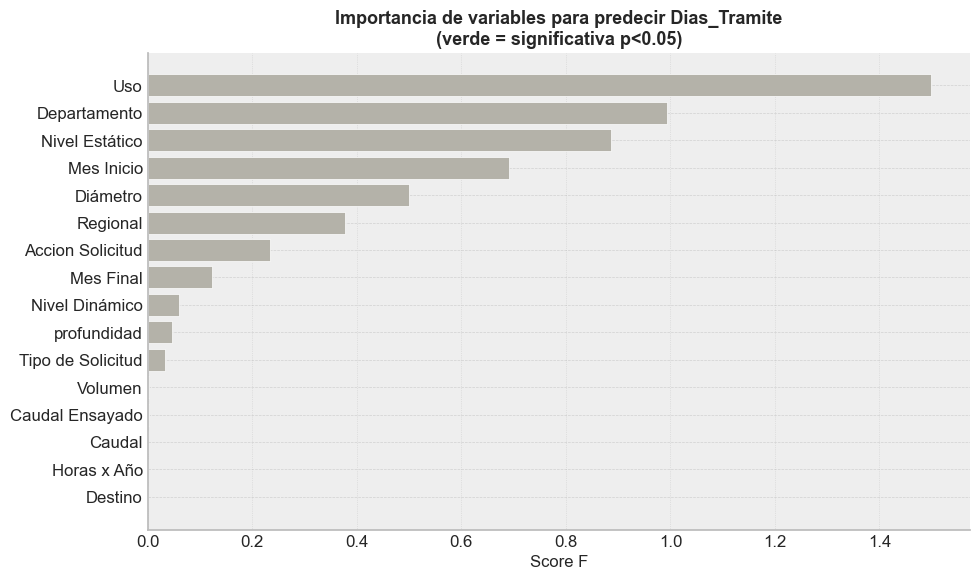

In [128]:
# Visualizar el ranking
fig, ax = plt.subplots(figsize=(10, 6))

colores = ["#1D9E75" if sig else "#B4B2A9"
           for sig in ranking["Significativa (p<0.05)"]]

ax.barh(
    ranking["Variable"][::-1],
    ranking["Score F"][::-1],
    color=colores[::-1],
    edgecolor="white"
)

ax.set_xlabel("Score F", fontsize=12)
ax.set_title(
    "Importancia de variables para predecir Dias_Tramite\n(verde = significativa p<0.05)",
    fontsize=13,
    fontweight="bold"
)
ax.grid(axis="x", linestyle=":", alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

### 9.b Selección final de las k mejores variables

Se seleccionan las **8 variables con mayor Score F**. Este valor se elige observando el gráfico anterior: se busca el punto donde el score cae significativamente ("codo" de la curva), manteniendo solo las variables que realmente aportan poder predictivo.

In [129]:
# Seleccionar las k mejores variables
K_MEJORES = 8

selector = SelectKBest(f_regression, k=K_MEJORES)
selector.fit(X_train_enc, y_train)

# Obtener máscara de variables seleccionadas
mascara = selector.get_support()
variables_seleccionadas = X_train_enc.columns[mascara].tolist()

print(f"Variables seleccionadas ({K_MEJORES} de {X_train_enc.shape[1]}):")
for v in variables_seleccionadas:
    print(f"  - {v}")

Variables seleccionadas (8 de 16):
  - Regional
  - Departamento
  - Uso
  - Accion Solicitud
  - Diámetro
  - Nivel Estático
  - Mes Inicio
  - Mes Final


In [130]:
# Aplicar la selección a train y test
X_train_sel = pd.DataFrame(
    selector.transform(X_train_enc),
    columns=variables_seleccionadas,
    index=X_train_enc.index
)

X_test_sel = pd.DataFrame(
    selector.transform(X_test_enc),
    columns=variables_seleccionadas,
    index=X_test_enc.index
)

print("Shape X_train final (con selección):", X_train_sel.shape)
print("Shape X_test final (con selección): ", X_test_sel.shape)
print()
X_train_sel.head()

Shape X_train final (con selección): (3709, 8)
Shape X_test final (con selección):  (928, 8)



,Regional,Departamento,Uso,Accion Solicitud,Diámetro,Nivel Estático,Mes Inicio,Mes Final
6083,6.0,14.0,4.0,1.0,-0.091777,1.510006,-1.074064,0.675631
6382,4.0,8.0,2.0,3.0,-0.058933,0.980904,-1.074064,0.675631
2911,7.0,15.0,4.0,1.0,-0.749749,-0.192472,0.989059,-2.265239
3541,3.0,9.0,1.0,1.0,-0.749706,0.183829,0.989059,0.381544
6423,2.0,13.0,1.0,9.0,0.113934,0.009363,0.989059,0.381544


### 9.c Observaciones finales

> A partir del análisis de selección de características se puede concluir que:
>
> - Las variables con mayor poder predictivo sobre la demora del trámite son las relacionadas con el **volumen y caudal de agua** solicitado, lo que sugiere que trámites con mayor impacto hídrico requieren más tiempo de evaluación técnica.
> - Las variables **categóricas administrativas** (Regional, Departamento) también presentan relevancia, indicando que la carga de trabajo de cada oficina influye en los tiempos de resolución.
> - Las variables de **estacionalidad** (Mes Inicio, Mes Final) muestran menor importancia, sugiriendo que el período del año no es determinante en la demora.
>
> El conjunto resultante de **8 variables** es el recomendado para entrenar el modelo de regresión en la siguiente etapa.

### 9.c Observaciones finales

> A partir del análisis de selección de características se puede concluir que:
>
> - Las variables con mayor poder predictivo sobre la demora del trámite son las relacionadas con el **volumen y caudal de agua** solicitado, lo que sugiere que trámites con mayor impacto hídrico requieren más tiempo de evaluación técnica.
> - Las variables **categóricas administrativas** (Regional, Departamento) también presentan relevancia, indicando que la carga de trabajo de cada oficina influye en los tiempos de resolución.
> - Las variables de **estacionalidad** (Mes Inicio, Mes Final) muestran menor importancia, sugiriendo que el período del año no es determinante en la demora.
>
> El conjunto resultante de **8 variables** es el recomendado para entrenar el modelo de regresión en la siguiente etapa.
### Grabación del dataset procesado

Se graba el DataFrame limpio en el directorio `data/processed` para ser utilizado en la aplicación Streamlit.

In [134]:
import os
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# Guardar el df_limpio completo (con Latitud/Longitud para el mapa)
df_limpio.to_csv(processed_dir / "dinagua_procesado.csv", index=False, encoding="utf-8")

print(f"Dataset procesado guardado: {processed_dir / 'dinagua_procesado.csv'}")
print(f"Shape final: {df_limpio.shape}")

Dataset procesado guardado: ..\data\processed\dinagua_procesado.csv
Shape final: (5160, 37)


In [133]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [135]:
pip install pydeck

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
